### Project Overview
This notebook implements a full end-to-end pipeline for the CSIRO Image2Biomass prediction task. 
https://www.kaggle.com/competitions/csiro-biomass/overview

The goal is to predict five biomass-related targets from plot images and associated metadata, with a competition metric based on Kaggle-style weighted R² over all targets.

raw CSV + JPEGs → processed folds → baselines → hybrid teacher → distilled student


In [ ]:
# ==================== 0. Setup Reproducibility & Config ====================
import os, random, platform
from dataclasses import dataclass, asdict
from pathlib import Path

# Make TensorFlow as deterministic as possible (given hardware / ops)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1" 
os.environ["PYTHONHASHSEED"] = str(42) 

import tensorflow as tf

tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
import cv2 # OpenCV (Open Source Computer Vision Library)
import sklearn

# Log library versions for reproducibility
versions = {
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "keras": tf.keras.__version__,
}
print("versions:", versions)

@dataclass
class CFG:
    """Global configuration for the CSIRO Image2Biomass project."""
    project_title: str = "CSIRO Image2Biomass Prediction"
    seed: int = 42
    image_size_h: int = 224
    image_size_w: int = 448 
    n_folds: int = 5
    batch_size: int = 8 # batch_size=8 for 357 images can be stable and better generalization
    raw_csv: str = "../../csiro-biomass/train.csv"
    image_root: str = "../../csiro-biomass"
    artifacts_dir: str = "./artifacts"
    figs_dir: str = "./figs"
    use_log1p: bool = False
    epochs: int = 10

CFG = CFG()
Path(CFG.artifacts_dir).mkdir(parents=True, exist_ok=True)
Path(CFG.figs_dir).mkdir(parents=True, exist_ok=True)

# ---------- Targets ----------
CORE_TARGETS = ["Dry_Green_g","Dry_Dead_g","Dry_Clover_g"]  
RAW_TARGETS  = CORE_TARGETS + ["GDM_g","Dry_Total_g"]       


# ---------- Reproducibility ----------
def set_seed(seed=42):
    """Set global random seed for Python, NumPy, and TensorFlow"""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(CFG.seed)

versions: {'python': '3.11.14', 'tensorflow': '2.17.1', 'numpy': '1.26.4', 'pandas': '2.3.3', 'sklearn': '1.7.2', 'keras': '3.12.0'}


In [2]:
# ==================== 1. read raw data ====================
df_raw = pd.read_csv(CFG.raw_csv)
display(df_raw.head(5))
# add tensor columns: abs_image_path & image_id
df_raw["abs_image_path"] = df_raw["image_path"].apply(lambda p: str(Path(CFG.image_root) / p))
df_raw["image_id"] = df_raw["abs_image_path"].map(lambda p: Path(p).stem)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [3]:

# ==================== 2. Pivot ====================
def build_pivot_df(df):
    """convert long-format biomass table to a wide per-image table."""
    
    # 1) create wide table which has one row per image with all 5 targets as columns
    wide = (
        df.pivot_table(index="image_id", # → each img is a row
                       columns="target_name", # → the target columns to create 
                       values="target",  # → the values to fill the table
                       aggfunc="first") # → in case of duplicates, take the first
          .reset_index() # → add the index column, so image_id becomes a column again
    )
    
    # 2)target columns check ensure all present
    for col in RAW_TARGETS:
        if col not in wide.columns:
            wide[col] = np.nan # add missing value target columns with NaN values
    wide = wide[["image_id"] + RAW_TARGETS]

    # Join metadata: from original df extract unique rows
    meta_cols = ["image_id", "abs_image_path", "Sampling_Date", "State", "Species", "Pre_GSHH_NDVI", "Height_Ave_cm"]
    meta = df[meta_cols].drop_duplicates("image_id") # drop duplicate rows based on image_id
    out = wide.merge(meta, on="image_id", how="left") # merge: use wide as base, left join meta

    cols =  meta_cols + RAW_TARGETS # reorder columns: metadata → targets(features first, then targets)
    return out[cols]

# create and save (CSV)
df_pivot = build_pivot_df(df_raw)

out_dir = Path(CFG.artifacts_dir)
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / "train_wide.csv"
df_pivot.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print("Pivot shape:", df_pivot.shape)


Saved: ../artifacts/train_wide.csv
Pivot shape: (357, 12)


In [4]:

# ==================== 3. Date features (update df_pivot)====================
from datetime import datetime
# 1) Date features
df_pivot["Sampling_Date"] = pd.to_datetime(df_pivot["Sampling_Date"], format="%Y/%m/%d", errors="coerce")
df_pivot["year"] = df_pivot["Sampling_Date"].dt.year
df_pivot["month"] = df_pivot["Sampling_Date"].dt.month
df_pivot["day_of_year"] = df_pivot["Sampling_Date"].dt.dayofyear

# 2) cyclical encodings
df_pivot['month_sin'] = np.sin(2 * np.pi * df_pivot['month'] / 12)
df_pivot['month_cos'] = np.cos(2 * np.pi * df_pivot['month'] / 12)
df_pivot['day_of_year_sin'] = np.sin(2 * np.pi * df_pivot['day_of_year'] / 365.25)
df_pivot['day_of_year_cos'] = np.cos(2 * np.pi * df_pivot['day_of_year'] / 365.25)

# 3) Categorical encoding (for tabular model)
# Convert "State" and "Species" features into numbers and save the mapping relationship for use during inference!
state_cat = df_pivot["State"].astype("category")    # 1. convert to category dtype
species_cat = df_pivot["Species"].astype("category")
df_pivot["State_encoded"] = state_cat.cat.codes     # 2. extract integer code as new column
df_pivot["Species_encoded"] = species_cat.cat.codes
STATE_MAP = dict(enumerate(state_cat.cat.categories)) # 3. create mapping dicts → int to category
SPECIES_MAP = dict(enumerate(species_cat.cat.categories))

# Reorder columns: metadata → targets
feature_cols = [col for col in df_pivot.columns if col not in RAW_TARGETS]
df_pivot = df_pivot[feature_cols + RAW_TARGETS]  # reorder columns: features first, then targets


In [5]:
# ==================== 4. StratifiedKFold by Species + Dry_Total_g ====================

from sklearn.model_selection import StratifiedKFold

# 1) Build stratification labels: Species + binned Dry_Total_g
y_for_bins = df_pivot["Dry_Total_g"]
if y_for_bins.isna().any():
    y_for_bins = (
        df_pivot["Dry_Green_g"] 
        + df_pivot["Dry_Dead_g"] 
        + df_pivot["Dry_Clover_g"]
    )

# Bin Dry_Total_g into 5 quantile-based buckets
bins = pd.qcut(y_for_bins, q=5, labels=False, duplicates="drop")

# Stratification label = species name + biomass bin index
strata = df_pivot["Species"].astype(str) + "_" + bins.astype(str)

# 2) StratifiedKFold: split into 5 folds, shuffled, stratified by `strata`
#    This is what makes each fold about 357 / 5 ≈ 71 samples.
skf = StratifiedKFold(
    n_splits=CFG.n_folds,   # decide how many folds → ~71 samples per fold
    shuffle=True,
    random_state=546195, # 7499
)

folds = np.full(len(df_pivot), -1)

for fold, (_, val_idx) in enumerate(skf.split(df_pivot, y=strata)):
    folds[val_idx] = fold

df_pivot["fold"] = folds.astype(int)

# 3) Sanity check: no species should appear in only a single fold
violations = []
species_counts = df_pivot["Species"].value_counts()

for sp, total in species_counts.items():
    per_fold = df_pivot[df_pivot["Species"] == sp]["fold"].value_counts()
    for fold_id, cnt in per_fold.items():
        if cnt == total:  # if this species is entirely contained in one fold
            violations.append((sp, fold_id, int(cnt), int(total)))

if violations:
    print("[Warn] Some species only appear in a single fold:")
    for sp, f, c, tot in violations:
        print(f"  - Species={sp}, fold={f}, count={c}/{tot}")
    # If you want to enforce this as a hard constraint, you can replace the
    # prints above with: `assert not violations`

# 4) Report: distribution of Dry_Total_g in each fold (original scale)
def fold_report(df):
    tgts = ["Dry_Green_g","Dry_Dead_g","Dry_Clover_g","GDM_g","Dry_Total_g"]
    return df.groupby("fold")[tgts].agg(["mean","std","min","max","count"]).round(2)

print("\n=== Fold report (on original scale, before any log transform) ===")
display(fold_report(df_pivot))

print("\n=== Fold sizes ===")
for fold_num in range(CFG.n_folds):
    print(f"Fold {fold_num}: {(df_pivot['fold'] == fold_num).sum()} samples")

# 5) save
processed_path = Path(CFG.artifacts_dir) / "train_processed.csv"
df_pivot.to_csv(processed_path, index=False)
print("Saved processed with folds to:", processed_path)


=== Fold report (on original scale, before any log transform) ===


/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Dry_Green_g                            Dry_Dead_g                     \
            mean    std   min     max count       mean    std  min    max   
fold                                                                        
0          25.67  22.78  0.00  129.34    72      13.57  15.35  0.0  83.84   
1          25.85  24.08  0.00  116.75    72      11.62  12.07  0.0  50.23   
2          28.72  29.14  0.00  119.60    71      10.11  11.21  0.0  53.26   
3          24.88  22.17  0.31   83.93    71      13.34  11.78  0.0  46.07   
4          28.04  28.56  0.00  157.98    71      11.57  11.09  0.0  52.93   

            ...  GDM_g                            Dry_Total_g               \
     count  ...   mean    std   min     max count        mean    std   min   
fold        ...                                                              
0       72  ...  31.24  21.65  1.40  129.34    72       44.80  28.16  6.30   
1       72  ...  33.00  24.31  3.78  116.75    72       44.63  24.36  9.20   
2       71  ...  36.44  27.72  1.80  119.60    71       46.54  31.75  2.48   
3       71  ...  32.14  22.23  2.40   96.76    71       45.49  24.89  4.30   
4       71  ...  33.59  28.45  1.04  157.98    71       45.15  30.77  1.04   

                   
        max count  
fold               
0     157.9    72  
1     120.4    72  
2     166.1    71  
3     119.1    71  
4     185.7    71  

[5 rows x 25 columns]


=== Fold sizes ===
Fold 0: 72 samples
Fold 1: 72 samples
Fold 2: 71 samples
Fold 3: 71 samples
Fold 4: 71 samples
Saved processed with folds to: ../artifacts/train_processed.csv


In [6]:

# ==================== 5. Label transform (log1p or gram) & Save processing_config ====================

# 1) Regardless of whether the current one is used or not, calculate the *_log column first (only once)
for t in RAW_TARGETS:
    neg_ct = (df_pivot[t] < 0).sum()
    if neg_ct > 0:
        print(f"[Warn] {t} has {neg_ct} negatives; clipping to 0 before log1p.")
        df_pivot.loc[df_pivot[t] < 0, t] = 0.0
        
for t in RAW_TARGETS:
    log_col = f"{t}_log"
    if log_col not in df_pivot.columns:
        df_pivot[log_col] = np.log1p(df_pivot[t].astype("float32"))
        
# ====================        

# 2) Define a helper to switch label mode (log1p vs gram)
def set_label_mode(use_log1p: bool):
    """
    Switch the target columns used during training:
        use_log1p=True → Use the *_log columns (log1p)
        use_log1p=False → Use the original gram columns 
    """
    global TRAIN_TARGETS, label_transform
    
    if not hasattr(CFG, 'use_log1p'):
        CFG.use_log1p = False
    
    CFG.use_log1p = use_log1p

    if use_log1p:
        TRAIN_TARGETS = [f"{t}_log" for t in RAW_TARGETS]
        label_transform = "log1p"
    else:
        TRAIN_TARGETS = RAW_TARGETS
        label_transform = "identity" # 'identity' means no transform / raw grams

    print(f"[set_label_mode] use_log1p={use_log1p} → TRAIN_TARGETS =", TRAIN_TARGETS)
    print(f"[init] fallback label_transform={label_transform}")
    
# 3) Set a default mode (e.g., gram) for preprocessing/config
set_label_mode(False)  # default set to gram
# ====================

# Overwrite save (contains both raw and *_log)
processed_path = Path(CFG.artifacts_dir) / "train_processed.csv"
df_pivot.to_csv(processed_path, index=False)
print("Saved (with log columns):", processed_path)

[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity
Saved (with log columns): ../artifacts/train_processed.csv


In [7]:

# ==================== 6. Config & Processed Data Saving ====================

from pathlib import Path
import json
from dataclasses import asdict
import numpy as np

# 1) Define the list of metadata features to be used
METADATA_FEATURES = [
    "Pre_GSHH_NDVI",      # Pre-season NDVI from satellite
    "Height_Ave_cm",      # Average plant height in cm
    "State_encoded",      # One-hot or label-encoded growth state
    "Species_encoded",    # Encoded plant species
    "year",               # Year of observation
    'month_sin',          # Cyclic encoding of month (sin)
    'month_cos',          # Cyclic encoding of month (cos)
    'day_of_year_sin',    # Cyclic encoding of day-of-year (sin)
    'day_of_year_cos',    # Cyclic encoding of day-of-year (cos)
]

# 2) Automatically separate categorical and continuous metadata columns
META_COLS_CAT  = [col for col in METADATA_FEATURES if 'encoded' in col]   # Categorical (already encoded)
META_COLS_CONT = [col for col in METADATA_FEATURES if col not in META_COLS_CAT]  # Continuous

# 3) Apply Z-score standardization to continuous metadata features
META_STATS = {}

for col in META_COLS_CONT:
    mean_val = float(df_pivot[col].mean())
    std_val  = float(df_pivot[col].std())
    
    # Avoid division by zero or NaN
    if std_val == 0 or np.isnan(std_val):
        std_val = 1.0
    
    META_STATS[col] = {"mean": mean_val, "std": std_val}
    df_pivot[col] = (df_pivot[col] - mean_val) / std_val

print(f"Standardized continuous metadata features: {META_COLS_CONT}")
print(f"Categorical (encoded) metadata features: {META_COLS_CAT}")
print("Meta stats:", META_STATS)

# 4) Build configuration dictionary and save processed data
config_dict = {
    # ==== Experiment hyperparameters ====
    **asdict(CFG),

    # ==== Label settings ====
    "label_transform": label_transform,
    "train_target_cols": TRAIN_TARGETS,       # Columns used for training
    "all_targets_raw": RAW_TARGETS,          # Raw physical targets
    "core_targets": CORE_TARGETS,            # (optional) Physical base components

    # ==== Metadata ====
    "metadata_features": METADATA_FEATURES,
    "metadata_categorical": META_COLS_CAT,
    "metadata_continuous": META_COLS_CONT,
    "meta_stats": META_STATS,

    # ==== Dataset statistics ====
    "n_samples": len(df_pivot),
    "n_unique_images": df_pivot["image_id"].nunique(),
    "n_metadata_features": len(METADATA_FEATURES),
    "n_categorical_meta": len(META_COLS_CAT),
    "n_continuous_meta": len(META_COLS_CONT),

    # ==== Lookup maps ====
    "State_map": STATE_MAP,
    "Species_map": SPECIES_MAP,
}


# Pretty-print the final config
print("\nFinal Configuration:")
print(json.dumps(config_dict, indent=4, ensure_ascii=False, default=str))

# 5) Save the processed training dataframe (with folds, normalized features, etc.)
processed_path = Path(CFG.artifacts_dir) / "train_processed.csv"
df_pivot.to_csv(processed_path, index=False)
# save json
config_json_path = Path(CFG.artifacts_dir) / "config.json"
config_json_path.parent.mkdir(parents=True, exist_ok=True)
with open(config_json_path, "w") as f:
    json.dump(config_dict, f, indent=4, ensure_ascii=False, default=str)
print("Saved processed data to:", processed_path)
print("Saved config to:", config_json_path)

Standardized continuous metadata features: ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'year', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']
Categorical (encoded) metadata features: ['State_encoded', 'Species_encoded']
Meta stats: {'Pre_GSHH_NDVI': {'mean': 0.6574229691876751, 'std': 0.1521422782849033}, 'Height_Ave_cm': {'mean': 7.595985434173669, 'std': 10.285262364329936}, 'year': {'mean': 2015.0, 'std': 1.0}, 'month_sin': {'mean': -0.2919126412355799, 'std': 0.6400249348408314}, 'month_cos': {'mean': -0.21040542495727946, 'std': 0.6806834220642672}, 'day_of_year_sin': {'mean': -0.2192218852635548, 'std': 0.6707198809798007}, 'day_of_year_cos': {'mean': -0.30936140111786986, 'std': 0.6393569352882097}}

Final Configuration:
{
    "project_title": "CSIRO Image2Biomass Prediction",
    "seed": 42,
    "image_size_h": 224,
    "image_size_w": 448,
    "n_folds": 5,
    "batch_size": 8,
    "raw_csv": "../csiro-biomass/train.csv",
    "image_root": "../csiro-biomass",
    "arti

## 2. images

In [8]:

import tensorflow as tf
from tensorflow.keras import layers

# ==================== 7. Augmentation primitives ====================

class ImageAugmentor(layers.Layer):
    """
    Custom Keras Layer for random image augmentation.
    
    Supports both:
      - Rank-3 inputs: (H, W, C)   → single image
      - Rank-4 inputs: (N, H, W, C) → batch of images
      
    Designed to be used:
      - Directly inside a Keras model (as a layer)
      - Or in tf.data pipelines via .map(tfdata_augmentor)
      
    Only augments the image (x), leaves labels (y) untouched.
    """
    
    def __init__(self, 
                 color_prob=0.15,
                #  gray_prob=0.0,
                 noise_prob=0.2,
                 blur_prob=0.2,
                 flip_lr_prob=0.5,
                 flip_ud_prob=0.3,
                 rot90_prob=0.5,
                 **kwargs):
        super().__init__(**kwargs)
        
        # augmentation config: (name, probability, apply function)
        self.ops = [
            ('Hue ±0.02', color_prob, 
             lambda x: tf.image.adjust_hue(x, tf.random.uniform([], -0.02, 0.02))),
            ('Saturation x1.1', color_prob, 
             lambda x: tf.image.adjust_saturation(x, tf.random.uniform([], 0.9, 1.1))),
            ('Brightness ±0.1', color_prob, 
             lambda x: tf.image.adjust_brightness(x, tf.random.uniform([], -0.1, 0.1))),
            ('Contrast x1.1', color_prob, 
             lambda x: tf.image.adjust_contrast(x, tf.random.uniform([], 0.9, 1.1))),
            # ('Grayscale', gray_prob, 
            #  lambda x: tf.image.grayscale_to_rgb(tf.image.rgb_to_grayscale(x))),
            ('Noise σ=0.02', noise_prob, 
             lambda x: x + tf.random.normal(tf.shape(x), stddev=0.02)),
            ('BoxBlur 3x3', blur_prob, 
             lambda x: tf.nn.avg_pool2d(x, 3, 1, 'SAME')),
            ('Flip LR', flip_lr_prob, 
             tf.image.flip_left_right),
            ('Flip UD', flip_ud_prob, 
             tf.image.flip_up_down),
            # ('Rotate 90°', rot90_prob, 
            #  lambda x: tf.image.rot90(x, k=1)),
        ]


    def get_visualization_ops(self, include_prob=False):
        """
        Helper to visualize what augmentations are applied (useful for debugging/logging).
        """
        if include_prob:
            return [(f"{name} ({prob:.0%})", fn) for name, prob, fn in self.ops]
        return [(name, fn) for name, prob, fn in self.ops]
    
    def call(self, x, training=None):
        """
        Keras Layer: g(x) -> x_aug
        - training=True/None: apply random augmentations
        - training=False: return img unchanged
        """
        # Handle single image (H,W,C) → temporarily add batch dim
        is_single = x.shape.rank == 3
        if is_single:
            x = x[None]  # (H,W,C) -> (1,H,W,C)
            
        # Default behavior in Keras: training=None means apply augmentations
        if training is None:
            training = True 
            
        # If training is a Tensor (e.g., traced in tf.data), use tf.cond to control overall logic
        def apply_all_ops(img):
            for _, prob, fn in self.ops:
                if prob > 0:
                    img = tf.cond(
                        tf.random.uniform(()) < prob,
                        lambda: tf.clip_by_value(fn(img), 0., 1.),
                        lambda: img,
                    )
            return img

        #  when training is a Tensor
        if isinstance(training, tf.Tensor):
            x = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_all_ops(x),
                lambda: x,
            )
        elif training:
            x = apply_all_ops(x)
            
        # Remove batch dim if input was a single image
        return x[0] if is_single else x

# Instantiate the augmentor layer (can be reused)
img_aug_layer = ImageAugmentor(name="augmentor")

# def tfdata_augmentor(x, y): # f(x, y) → (x_aug, y)
#     return img_aug_layer(x, training=True), y


def tfdata_augmentor(x, y):
    """
    Universal augmentation wrapper for tf.data pipelines.
    
    Supports two input formats:
      - Image-only: x is a Tensor (H,W,C) or (N,H,W,C)
      - Hybrid model: x is a dict with key 'image'
      
    Returns: (x_augmented, y) — labels unchanged
    """
    # Case 1: x = (image, metadata)
    if isinstance(x, dict):
        x = dict(x)  # shallow copy to avoid mutating original
        x["image"] = img_aug_layer(x["image"], training=True)
        return x, y
    # Case 2: x = image only
    else:
        x_aug = img_aug_layer(x, training=True)
        return x_aug, y


def tfdata_clip(x, y): # Numerical Safety / Clamping
    """
    Universal clipping function (ensures pixel values stay in [0, 1]).
    Works with both image-only and dict-style inputs.
    """
    if isinstance(x, dict):
        x = dict(x)
        x["image"] = tf.clip_by_value(x["image"], 0.0, 1.0)
        return x, y
    else:
        return tf.clip_by_value(x, 0.0, 1.0), y


In [ ]:

# ==================== 8. BiomassImgDataModule  ====================

class BiomassImgDataModule:
    def __init__(self, 
                 fold: int = 3, 
                 target_list: list = None,
                 include_meta: bool = False,
                 aux_targets: bool = False
    ): 
        """
        include_meta=True  -> metadata as INPUT (Teacher)
        aux_targets=True   -> metadata as OUTPUT (auxiliary targets for multi-task)
        
        y shape:
          aux_targets=False: (N, len(target_list))  # biomass only
          aux_targets=True : (N, len(target_list) + 4)
                              [biomass, NDVI, Height, Species_label, State_label]
        """
        self.fold = fold
        self.include_meta = include_meta       # <--- 2. include tabular
        self.aux_targets = aux_targets   
        
        if target_list is None:
            target_list = TRAIN_TARGETS
        self.target_list = target_list

        self.IMG_SIZE = (CFG.image_size_h, CFG.image_size_w)

        # --------------------- Load processed data ---------------------
        pivot_path = out_dir / "train_processed.csv"
        assert pivot_path.exists(), f"Missing: {pivot_path}"
        df = pd.read_csv(pivot_path)
        
        # Drop rows missing any target (critical for regression)
        df = df.dropna(subset=self.target_list).reset_index(drop=True)

        self.df = df
        # --------------------- core biomass targets (always first)  ---------------------
        # self.y = df[self.target_list].astype("float32").values  # (N, 5)
        y = df[self.target_list].astype("float32").values  # (N, T_biomass)
        
        # --------------------- optionally append aux metadata targets ---------------------
        # [Biomass (5)] =concatenate=> [Biomass (5)] + [NDVI] + [Height] + [species] + [State]
        # Extra outputs (auxiliary):
        # NDVI (Pre_GSHH_NDVI) – regression
        # Height (Height_Ave_cm) – regression
        # Species (Species_encoded) – classification
        # State (State_encoded) – classification
        if self.aux_targets:
            # two continuous aux targets (already standardized)
            aux_cont_cols = ["Pre_GSHH_NDVI", "Height_Ave_cm"]
            y_aux_cont = df[aux_cont_cols].astype("float32").values  # (N, 2)

            # two categorical aux targets (integer labels)
            y_species = df["Species_encoded"].astype("float32").values[:, None]  # (N,1)
            y_state   = df["State_encoded"].astype("float32").values[:, None]    # (N,1)

            y = np.concatenate([y, y_aux_cont, y_species, y_state], axis=1)

        self.y = y

        # --------------------- optionally Metadata preprocessing ---------------------
        if self.include_meta:
            self.meta_cols_cat  = META_COLS_CAT
            self.meta_cols_cont = META_COLS_CONT
            
            # Fill NaN in continuous metadata (common & safe default)
            self.df[self.meta_cols_cont] = self.df[self.meta_cols_cont].fillna(0.0)
            
    def load_img(self, path: str):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        img = cv2.resize(
            img,
            (self.IMG_SIZE[1], self.IMG_SIZE[0]), 
            interpolation=cv2.INTER_AREA
        )
        return img.astype("float32") / 255.0

    def make_arrays(self):
        # imgs → N x H x W x C
        imgs = np.stack([self.load_img(p) for p in self.df["abs_image_path"]])
        return imgs

    def make_datasets(self):
        imgs = self.make_arrays()
        y = self.y # y → N x T

        val_mask = (self.df["fold"] == self.fold).values
        tr_idx = np.where(~val_mask)[0]
        va_idx = np.where(val_mask)[0]

        print(f"Fold {self.fold} | Target: {self.target_list}")
        print(f"  Train: {len(tr_idx)} images | Val: {len(va_idx)} images")
        
        # ==========================================
        # Core Logic: Choose input format based on whether metadata is used
        # ==========================================
        if self.include_meta:
            # Mode A: Hybrid (Teacher) -> Returns a dictionary of inputs
            # Useful for models that accept multiple inputs (image + tabular metadata)
            meta_cont = self.df[self.meta_cols_cont].astype("float32").values # (N, 7)
            meta_cat  = self.df[self.meta_cols_cat].astype("int32").values # (N, 2)
            
            # Dataset yields (dict_of_inputs, labels)
            train_inputs = {
                "image":     imgs[tr_idx],
                "meta_cont": meta_cont[tr_idx],
                "meta_cat":  meta_cat[tr_idx],
            }
            val_inputs = {
                "image":     imgs[va_idx],
                "meta_cont": meta_cont[va_idx],
                "meta_cat":  meta_cat[va_idx],
            }

            train_ds = tf.data.Dataset.from_tensor_slices((train_inputs, y[tr_idx]))
            val_ds   = tf.data.Dataset.from_tensor_slices((val_inputs,   y[va_idx]))

        else:
            # Mode B: Image Only (Baseline / Student) -> Returns Tensor
            # Simpler and faster - perfect for pure CNNs or knowledge distillation students
            train_ds = tf.data.Dataset.from_tensor_slices((imgs[tr_idx], y[tr_idx]))
            val_ds   = tf.data.Dataset.from_tensor_slices((imgs[va_idx], y[va_idx]))


        # ==========================================
        # Pipeline (for all model)
        # ==========================================
        print(f"Fold {self.fold} | Meta={self.include_meta} | Train:{len(tr_idx)} Val:{len(va_idx)}")
        
        # Create Image Data Pipeline
        train_ds = (
            train_ds
            .map(tfdata_augmentor, num_parallel_calls=1)# x passed to aug function, preprocessing + Augmentation
            .shuffle(1024, seed=CFG.seed, reshuffle_each_iteration=False) # Shuffle order
            .batch(CFG.batch_size)  # batching
            .prefetch(1) # prefetch for performance(speed up training, important!)
        )

        val_ds = (
            val_ds
            .map(tfdata_clip, num_parallel_calls=1)
            .batch(CFG.batch_size)
            .prefetch(1)
        )

        return train_ds, val_ds


## 3. cnn model

$$\text{R}^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}  -->  weight R^2$$


The metric does *not* calculate five separate R2 scores and average them. 

Instead, it flattens all predictions and true values into single, long vectors before computing one R2 score.


$\text{R}^2$ CalculationThe weighted coefficient of determination $\mathbf{R}_w^2$ is calculated as:$$R_w^2 = 1 - \frac{\sum_j w_j(y_j - \hat{y}_j)^2}{\sum_j w_j(y_j - \bar{y}_w)^2}$$where the global weighted mean $\bar{y}_w$ is:$$\bar{y}_w = \frac{\sum_j w_j y_j}{\sum_j w_j}$$Residual Sum of Squares $SS_{\text{res}}$ Measures the total error of the model's predictions:$$SS_{\text{res}} = \sum_j w_j(y_j - \hat{y}_j)^2$$Total Sum of Squares $SS_{\text{tot}}$ Measures the total weighted variance in the data:$$SS_{\text{tot}} = \sum_j w_j(y_j - \bar{y}_w)^2$$

Terms 

$\mathbf{y}_j$: ground-truth value for data point $j$ 

$\mathbf{\hat{y}}_j$ : model prediction for data point $j$ 

$\mathbf{w}_j$ : per-row weight based on target type

$\mathbf{\bar{y}}_w$ : global weighted mean of all ground-truth values

Add penalty to the loss (5‑head case)
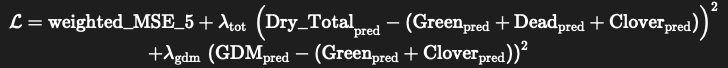

In [10]:
# ==================== 9. Weighted R² metric  ====================
import numpy as np
import pandas as pd

COMP_WEIGHTS = {
   "Dry_Green_g": 0.1,
   "Dry_Dead_g": 0.1,
   "Dry_Clover_g": 0.1,
   "GDM_g": 0.2,
   "Dry_Total_g": 0.5,
}

# LOSS_WEIGHTS_RAW = [COMP_WEIGHTS[t] for t in RAW_TARGETS]

# get_loss_weights(TRAIN_TARGETS) = [0.1,0.1,0.1,0.2,0.5]
# Loss weights for the three core competition targets
# loss_weights = get_loss_weights(target_names)


def weighted_r2_kaggle(df_true, df_pred):
    """
    df_true, df_pred: DataFrame, with columns:
      ['Dry_Green_g','Dry_Dead_g','Dry_Clover_g','GDM_g','Dry_Total_g']
    All values are on the ORIGINAL scale (grams), no logs.
    """
    # 1. Iterate & Collect: Loop through the five target columns. 
    # For each, create arrays for true values (y), predictions (yp), and the corresponding competition weight (w).
    y_list, yp_list, w_list = [], [], []

    cols = ["Dry_Green_g","Dry_Dead_g","Dry_Clover_g","GDM_g","Dry_Total_g"]
    for col in cols:
        y  = df_true[col].astype("float64").values
        yp = df_pred[col].astype("float64").values
        w  = np.full_like(y, fill_value=COMP_WEIGHTS[col], dtype="float64")

        y_list.append(y)
        yp_list.append(yp)
        w_list.append(w)

    # 2. Concatenate: The core step. 
    # Combine the lists of arrays into three single, flat NumPy arrays: y_all, y_all, and w_all.
    y_all  = np.concatenate(y_list)      # all (image, target) in one array
    yp_all = np.concatenate(yp_list)
    w_all  = np.concatenate(w_list)

    # 3. Global weighted average
    y_bar_w = np.sum(w_all * y_all) / np.sum(w_all)

    # 4. Calculate Weighted Mean (y_bar_w):
    # Compute the global weighted average of the true values. This is the baseline for the R2 calculation.
    ss_res = np.sum(w_all * (y_all - yp_all)**2)
    
    # 5. Compute Sum of Squares: Calculate the weighted residual sum of squares (ss_res) and the weighted total sum of squares (ss_tot).
    ss_tot = np.sum(w_all * (y_all - y_bar_w)**2)
    
    # 5. Final R2 Score: Apply the final formula:
    # The small epsilon has 1e-12 is for numerical stability.
    r2w = 1.0 - ss_res / (ss_tot + 1e-12)
    
    return float(r2w)
      
# ==================================================================

def eval_weighted_r2_in_gram(
        val_df: pd.DataFrame,
        y_pred_default: np.ndarray,
        model_name: str = "",
        fold: int | None = None):
    """
    Evaluate model predictions using Kaggle-style Weighted R² in gram space.

    Args:
        val_df (DataFrame): Ground-truth labels in gram units.
        y_pred_default (ndarray): Model outputs (log1p or gram), shape (N, 3).
        model_name (str, optional): Name for logging.
        fold (int, optional): Fold index for logging.

    Returns:
        tuple: (weighted_r2, pred_df, true_df)
    """
    # 1) Convert model outputs to gram space based on the current label mode. log1p → gram /  gram
    if CFG.use_log1p:
        # default outputs are log1p → convert back to grams
        y_pred_gram = np.expm1(y_pred_default)
    else:
        # default outputs are already in grams
        y_pred_gram = y_pred_default
        
    n_out = y_pred_gram.shape[1]
    
    # 2) Build prediction DataFrame depending on output dimension. # pred_df
    if n_out == 3:
         # Old behavior: model outputs 3 core targets, we derive GDM & Dry_Total
        # Extract the three core targets
        dg_p = y_pred_gram[:, 0]
        dd_p = y_pred_gram[:, 1]
        dc_p = y_pred_gram[:, 2]

        # Construct prediction DataFrame (including derived GDM / Dry_Total)
        pred_df = pd.DataFrame({
            "Dry_Green_g":  dg_p,
            "Dry_Dead_g":   dd_p,
            "Dry_Clover_g": dc_p,
        })
        pred_df["GDM_g"]       = pred_df["Dry_Green_g"] + pred_df["Dry_Clover_g"]
        pred_df["Dry_Total_g"] = pred_df["Dry_Green_g"] + pred_df["Dry_Dead_g"] + pred_df["Dry_Clover_g"]
        
    elif n_out == 5:
        # New behavior: model directly outputs 5 targets in order RAW_TARGETS
        pred_df = pd.DataFrame(
            y_pred_gram,
            columns=["Dry_Green_g",
                     "Dry_Dead_g",
                     "Dry_Clover_g",
                     "GDM_g",
                     "Dry_Total_g"]
        )
    else:
        raise ValueError(f"Expected model to output 3 or 5 targets, got shape {y_pred_gram.shape}")


    # 3) Ground truth (always in gram space)
    true_df = val_df[[
        "Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"
    ]].copy()

    # 4) Compute Weighted R²
    w_r2 = weighted_r2_kaggle(true_df, pred_df)

    tag = f"[{model_name}] " if model_name else ""
    if fold is not None:
        print(f"{tag}Fold {fold} Kaggle-style weighted R2 = {w_r2:.4f}")
    else:
        print(f"{tag}Kaggle-style weighted R2 = {w_r2:.4f}")

    return w_r2, pred_df, true_df

# ==================================================================
def get_loss_weights(target_names):
    """
    Given a list of training target column names (possibly *_log),
    return the per-target weights aligned with COMP_WEIGHTS.

    Example:
        target_names = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g"]
        or         = ["Dry_Green_g_log", ...] in log1p mode.

    Returns:
        list[float]: weights in the same order as target_names.
    """
    base_names = [name.replace("_log", "") for name in target_names]
    return [COMP_WEIGHTS[n] for n in base_names]

def constrained_weighted_mse_loss(
    target_names,
    lambda_total=0.1, 
    lambda_gdm=0.1,
    max_err=None,
):
    """
    Weighted MSE over all targets + penalties enforcing:
      - Dry_Total ≈ Dry_Green + Dry_Dead + Dry_Clover
      - GDM      ≈ Dry_Green + Dry_Clover

    Works with both gram and log1p modes (penalty applied in gram space).
    """
    # same weights you already use
    weights = get_loss_weights(target_names)
    w = tf.constant(weights, tf.float32)

    # map from raw name to index, handling *_log columns
    base_names = [n.replace("_log", "") for n in target_names]

    def idx(raw_name: str) -> int:
        return base_names.index(raw_name)

    i_g   = idx("Dry_Green_g")
    i_d   = idx("Dry_Dead_g")
    i_c   = idx("Dry_Clover_g")
    i_gdm = idx("GDM_g")
    i_tot = idx("Dry_Total_g")

    def loss_fn(y_true, y_pred):
        # ----- 1) usual weighted MSE in label space (log or gram) -----
        err = y_true - y_pred
        if max_err is not None:
            err = tf.clip_by_value(err, -max_err, max_err)
        mse = tf.reduce_mean(tf.square(err) * w)

        # ----- 2) structural penalty in GRAM space -----
        if CFG.use_log1p:
            y_pred_gram = tf.expm1(y_pred)
        else:
            y_pred_gram = y_pred

        g   = y_pred_gram[:, i_g]
        d   = y_pred_gram[:, i_d]
        c   = y_pred_gram[:, i_c]
        gdm = y_pred_gram[:, i_gdm]
        tot = y_pred_gram[:, i_tot]

        penalty_gdm   = tf.reduce_mean(tf.square(gdm - (g + c)))
        penalty_total = tf.reduce_mean(tf.square(tot - (g + d + c)))

        return mse + lambda_gdm * penalty_gdm + lambda_total * penalty_total

    loss_fn.__name__ = "constrained_weighted_mse_loss"
    return loss_fn

# ===============Multi‑task loss: biomass + metadata=================
# Key Idea: 
# Our new loss function must grade the model on everything at once: 
# the main quest (biomass) and all the side quests (metadata). 
# We'll balance them with weights.
# L=Lbiomass​+λaux,cont​(MSE(NDVI)+MSE(Height))+λaux,cat​(CE(Species)+CE(State))
def multitask_biomass_aux_loss_with_constraints(
    target_names,
    lambda_aux_cont=0.3,   # weight on NDVI + Height MSE
    lambda_aux_cat=0.3,    # weight on Species + State CE
    lambda_total=0.1,      # Dry_Total constraint weight
    lambda_gdm=0.1,        # GDM constraint weight
    max_err=None,          # max error for constrained_weighted_mse_loss
):
    """
    y_true layout: [5 biomass, 1 NDVI, 1 Height, 1 species_label, 1 state_label]
    y_pred layout: [5 biomass, 1 NDVI, 1 Height, n_species logits, n_states logits]
    """
    n_biomass = len(target_names)
    n_species = len(SPECIES_MAP)
    n_states  = len(STATE_MAP)

    biomass_loss_fn = constrained_weighted_mse_loss(
        target_names=target_names,
        lambda_total=lambda_total,
        lambda_gdm=lambda_gdm,
        max_err=max_err,
    )

    # ---- indices in y_true ----
    T_IDX_NDVI          = n_biomass        # scalar
    T_IDX_HEIGHT        = n_biomass + 1    # scalar
    T_IDX_SPECIES_LABEL = n_biomass + 2    # scalar (int)
    T_IDX_STATE_LABEL   = n_biomass + 3    # scalar (int)

    # ---- indices in y_pred ----
    P_IDX_NDVI           = n_biomass
    P_IDX_HEIGHT         = n_biomass + 1
    P_IDX_SPECIES_START  = n_biomass + 2
    P_IDX_SPECIES_END    = P_IDX_SPECIES_START + n_species
    P_IDX_STATE_START    = P_IDX_SPECIES_END
    P_IDX_STATE_END      = P_IDX_STATE_START + n_states

    def loss_fn(y_true, y_pred):
        # ----- 1) biomass weighted MSE -----
        y_true_b = y_true[:, :n_biomass]       # (B, 5)
        y_pred_b = y_pred[:, :n_biomass]       # (B, 5)  (biomass_head)
        biomass_loss = biomass_loss_fn(y_true_b, y_pred_b)

        # ----- 2) auxiliary continuous (NDVI, Height) -----
        ndvi_true   = y_true[:, T_IDX_NDVI]
        height_true = y_true[:, T_IDX_HEIGHT]

        ndvi_pred   = y_pred[:, P_IDX_NDVI]
        height_pred = y_pred[:, P_IDX_HEIGHT]

        mse_ndvi   = tf.reduce_mean(tf.square(ndvi_true - ndvi_pred))
        mse_height = tf.reduce_mean(tf.square(height_true - height_pred))

        aux_cont_loss = mse_ndvi + mse_height

        # ----- 3) auxiliary categorical (Species, State) -----
        species_true = tf.cast(y_true[:, T_IDX_SPECIES_LABEL], tf.int32)
        state_true   = tf.cast(y_true[:, T_IDX_STATE_LABEL], tf.int32)

        species_logits = y_pred[:, P_IDX_SPECIES_START:P_IDX_SPECIES_END]
        state_logits   = y_pred[:, P_IDX_STATE_START:P_IDX_STATE_END]

        ce_species = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=species_true, logits=species_logits
            )
        )
        ce_state = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=state_true, logits=state_logits
            )
        )

        aux_cat_loss = ce_species + ce_state

        return biomass_loss + lambda_aux_cont * aux_cont_loss + lambda_aux_cat * aux_cat_loss

    loss_fn.__name__ = "multitask_biomass_aux_loss_with_constraints"
    return loss_fn


In [11]:
# ==================== 10. backbone ====================
# this model, it uses ONLY pure image data — no tabular features at all!

from tensorflow.keras import layers, models, optimizers, callbacks
def make_mae_metrics(target_names):
    """
    Metrics only on the first len(target_names) dims (biomass),
    so it's compatible with multi-task outputs that have extra heads.
    """
    n_targets = len(target_names)

    def mae_all(y_true, y_pred):
        # Only evaluate on the ground truth part (first half)
        # We've always sliced y_true for distillation tasks
        y_true_core = y_true[:, :n_targets]  
        # This tells our scorecard:
        # "Only grade the first 5 biomass outputs.
        # The rest is just for training!"
        y_pred_core = y_pred[:, :n_targets]
        return tf.reduce_mean(tf.abs(y_true_core - y_pred_core))

    mae_all.__name__ = "mae_all"
    metric_list = [mae_all]

    def make_fn(idx, name):
        def mae_i(y_true, y_pred):
            y_pred_core = y_pred[:, :n_targets]
            y_true_core = y_true[:, :n_targets]
            return tf.reduce_mean(tf.abs(y_true_core[:, idx] - y_pred_core[:, idx]))
        mae_i.__name__ = name
        return mae_i

    for i, tname in enumerate(target_names):
        metric_list.append(make_fn(i, f"mae_{tname}"))
    return metric_list


# === shared image backbone ===
def build_image_backbone(
    image_size_h: int = CFG.image_size_h,
    image_size_w: int = CFG.image_size_w,
    name: str = "ImageBackbone",
):
    """Build a basic CNN backbone for image feature extraction.

    Args:
        image_size_h: Input image height in pixels.
        image_size_w: Input image width in pixels.

    Returns:
        tf.keras.Model: CNN backbone mapping (H, W, 3) → (batch, 256) features.
    """
    
    img_shape = (image_size_h, image_size_w, 3)
    inputs = layers.Input(shape=img_shape)

    x = layers.Conv2D(16, 3, padding="same", activation=None,
                      kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 112x224

    x = layers.Conv2D(32, 3, padding="same", activation=None,
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 56x112

    x = layers.Conv2D(64, 3, padding="same", activation=None,
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 28x56

    x = layers.Conv2D(256, 3, padding="same", activation=None,
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)   # -> (batch, 256)

    backbone = models.Model(inputs=inputs, outputs=x, name=name)
    return backbone

In [12]:

# ==================== 11A. BiomassConvBaseline (multi-target CNN regressor) ====================
#  Multi‑task CNN with 5 biomass heads + aux heads 
# Key idea in Inter: A single output layer isn't enough anymore. 
# Our model needs a separate "head" for each task it's trying to solve, all sharing the same "body".
# We'll create a new model builder, biomass_conv_multitask, that implements our multi-headed design. 
# It's like assembling LEGOS.
def biomass_conv_baseline(
    image_size_h: int = CFG.image_size_h,
    image_size_w: int = CFG.image_size_w,
    target_names: list | None = None,
    lambda_aux_cont: float = 0.3,
    lambda_aux_cat: float = 0.3,
) -> tf.keras.Model:
    """
    Image-only CNN with:
      - 5 biomass heads (as before)
      - aux heads for NDVI, Height, Species, State

    Output vector layout:
      [5 biomass, 1 NDVI, 1 Height, n_species logits, n_states logits]
    """
    if target_names is None:
        target_names = TRAIN_TARGETS
    n_biomass = len(target_names)
    n_species = len(SPECIES_MAP)
    n_states  = len(STATE_MAP)
    
    # Shared image backbone, as a layer for any model
    backbone = build_image_backbone(image_size_h, image_size_w, name="ImageBackbone")
    img_inputs = layers.Input(shape=(image_size_h, image_size_w, 3), name="image")
    # the shared body and brain
    x = backbone(img_inputs)
    
    # Head: regression part
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # 5 biomass heads (non-negative)
    # create a separate head for each task
    biomass_out = layers.Dense(
        n_biomass,
        activation="softplus",# Softplus to ensure non-negative outputs
        name="biomass_head",
        dtype="float32",
    )(x)
    # ==================== 
    # aux regression heads
    ndvi_out   = layers.Dense(1, activation=None, name="ndvi_head")(x)
    height_out = layers.Dense(1, activation=None, name="height_head")(x)

    # aux classification heads (logits)
    species_logits = layers.Dense(
        n_species, activation=None, name="species_head"
    )(x)
    state_logits = layers.Dense(
        n_states, activation=None, name="state_head"
    )(x)


    # concatenate all heads into a single output vector
    outputs = layers.Concatenate(name="all_heads")(
        [biomass_out, ndvi_out, height_out, species_logits, state_logits]
    )
    # ==================== 
    model = models.Model(
        inputs=img_inputs,
        outputs=outputs,
        name="BiomassConvMultitask",
    )

    loss_fn = multitask_biomass_aux_loss_with_constraints(
        target_names=target_names,
        lambda_aux_cont=lambda_aux_cont,
        lambda_aux_cat=lambda_aux_cat,
        lambda_total=0.1,
        lambda_gdm=0.1,
        max_err=200.0,
    )
    print(f"[biomass_conv_baseline] using loss = {loss_fn.__name__}")
    
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=make_mae_metrics(target_names),
    )
    return model


In [13]:
# ==================== 11.0. refers: true Mean baseline ≈ 0.24  ====================
def mean_baseline_r2_for_fold(fold: int):
    """
    Compute weighted R² for a per-fold mean target baseline.

    For the given fold, this baseline predicts the mean of each target
    (computed on the training split) for all validation samples, then
    evaluates Kaggle-style weighted R².

    Args:
        fold: Fold index to use as validation split.

    Returns:
        float: Weighted R² score for this fold.
    """
    dm = BiomassImgDataModule(fold=fold, target_list=TRAIN_TARGETS)

    val_mask  = (dm.df["fold"] == fold).values
    train_mask = ~val_mask

    train_df = dm.df[train_mask].reset_index(drop=True)
    val_df   = dm.df[val_mask].reset_index(drop=True)

    # mean of train_df (gram)
    mean_df = train_df[["Dry_Green_g","Dry_Dead_g","Dry_Clover_g"]].mean()

    n_val = len(val_df)
    pred_df = pd.DataFrame({
        "Dry_Green_g":  np.full(n_val, mean_df["Dry_Green_g"]),
        "Dry_Dead_g":   np.full(n_val, mean_df["Dry_Dead_g"]),
        "Dry_Clover_g": np.full(n_val, mean_df["Dry_Clover_g"]),
    })
    pred_df["GDM_g"]       = pred_df["Dry_Green_g"] + pred_df["Dry_Clover_g"]
    pred_df["Dry_Total_g"] = pred_df["Dry_Green_g"] + pred_df["Dry_Dead_g"] + pred_df["Dry_Clover_g"]

    true_df = val_df[[
        "Dry_Green_g","Dry_Dead_g","Dry_Clover_g","GDM_g","Dry_Total_g"
    ]].copy()

    r2 = weighted_r2_kaggle(true_df, pred_df)
    print(f"[Mean baseline] Fold {fold}: weighted R² = {r2:.4f}")
    return r2

mean_r2 = []
for f in range(CFG.n_folds):
    mean_r2.append(mean_baseline_r2_for_fold(f))

print("Mean-baseline R² per fold:", np.round(mean_r2, 3),
      "mean =", np.mean(mean_r2))


[Mean baseline] Fold 0: weighted R² = 0.2467
[Mean baseline] Fold 1: weighted R² = 0.2703
[Mean baseline] Fold 2: weighted R² = 0.2077
[Mean baseline] Fold 3: weighted R² = 0.2795
[Mean baseline] Fold 4: weighted R² = 0.2122
Mean-baseline R² per fold: [0.247 0.27  0.208 0.279 0.212] mean = 0.24327056587010784


3 target:
Mean-baseline R² per fold: [0.247 0.27  0.208 0.279 0.212] mean = 0.24327056587010784

In [14]:


# ==================== 11. one fold train generic model ====================

from tensorflow.keras import callbacks

def build_callbacks(monitor, mode):
    """Create standard training callbacks.

    Args:
        monitor: Metric name to monitor (e.g. "val_mae_all").
        mode: "min" or "max", passed to Keras callbacks.

    Returns:
        list: [EarlyStopping, ReduceLROnPlateau] callbacks.
    """
    rlr = callbacks.ReduceLROnPlateau(
        monitor=monitor,
        mode=mode,                
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    )
    es = callbacks.EarlyStopping(
        monitor=monitor,
        mode=mode,
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )
    return [es, rlr] # callbacks_list, early_stopping


def build_val_inputs(
    dm: BiomassImgDataModule,
    fold: int,
    include_meta: bool,
):
    """Build validation inputs for R² evaluation.

    Args:
        dm: Data module holding processed DataFrame and image arrays.
        fold: Fold index to select validation rows.
        include_meta: If True, return dict(image + metadata); otherwise images only.

    Returns:
        tuple:
            - val_df (pd.DataFrame): Validation rows in gram space.
            - x_val: Validation inputs for model.predict (tensor or dict).
    """
    # 1) Select the current fold's val df (with 5 real targets in GRAM space)
    val_mask = (dm.df["fold"] == fold).values
    val_df   = dm.df[val_mask].reset_index(drop=True)

    # 2) prepare val img array
    imgs_all = dm.make_arrays()              # (N, H, W, 3)
    imgs_val = imgs_all[val_mask]            # (N_val, H, W, 3)

    # 3)Decide the structure of x_val based on include_meta
    # include_meta=False → image-only pipeline + x_val = imgs_val
    # include_meta=False → image-only pipeline + x_val = imgs_val
    # CFG.use_log1p control log/gram
    if include_meta:
        # Teacher: image + tabular dict
        meta_cont_all = dm.df[dm.meta_cols_cont].astype("float32").values
        meta_cat_all  = dm.df[dm.meta_cols_cat ].astype("int32").values

        meta_cont_val = meta_cont_all[val_mask]
        meta_cat_val  = meta_cat_all[val_mask]

        x_val = {
            "image":     imgs_val,
            "meta_cont": meta_cont_val,
            "meta_cat":  meta_cat_val,
        }
    else:
        # Baseline: image only
        x_val = imgs_val
    return val_df, x_val


def train_one_fold_generic(
    fold,
    *,
    include_meta: bool,
    model_fn,
    model_name: str,
    target_list=None,
    aux_targets: bool = False,
    **model_kwargs, #  baseline_weights_path=baseline_ckpt pass to model_fn
):
    """
    Train one fold.

    If target_list is None, default to TRAIN_TARGETS.
    When using log1p, TRAIN_TARGETS should be the *_log names if CFG.use_log1p is True.
    Args:
        fold: which fold index to use as validation.
        target_list: list of target column names; default = TRAIN_TARGETS.
        model_fn: a function that builds and returns a compiled Keras model.
                  Signature: model_fn(image_size_h, image_size_w, target_names, **model_kwargs)
        model_kwargs: extra keyword args passed to model_fn (e.g. backbone_trainable_ratio).
    Returns:
        tuple: (best_val_mae, model, history, val_ds, w_r2)
    """
    
    if target_list is None:
        target_list = TRAIN_TARGETS

    print(f"\n===== Fold {fold} =====")
    print(f"[Baseline] use_log1p={CFG.use_log1p}, target_list={target_list}")

    # ---- Choose a fold for validation and train ----
    dm = BiomassImgDataModule(
        fold=fold, 
        target_list=target_list,
        include_meta=include_meta,   # <--- baseline exclude tabular,image only
        aux_targets=aux_targets, 
    )
    train_ds, val_ds = dm.make_datasets()
  
    # ---- create model ----
    model = model_fn( # 9A.biomass_conv_baseline
        image_size_h = CFG.image_size_h, 
        image_size_w = CFG.image_size_w,
        target_names=target_list,
        **model_kwargs,
    )
  
    # ---- callbacks ----
    callbacks_list = build_callbacks(monitor="val_mae_all", mode="min")
    
    # ---- Train fold ----
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CFG.epochs,
        callbacks=callbacks_list,
        verbose=1,
    )

    # ---- Evaluate fold ----
    #  Get best val_mae_all from 5 folds history
    best_val_mae = min(history.history["val_mae_all"])
    print(f"Fold {fold} best val_mae_all = {best_val_mae:.3f}")
    
    
    # =========  Weighted R² (eval ALWAYS in gram)  ========
    # build_val_inputs + eval_weighted_r2_in_gram
    
    # 1) Construct val_df + x_val (image-only or image+meta)
    val_df, x_val = build_val_inputs(
        dm=dm,
        fold=fold,
        include_meta=include_meta,
    )

    # # 2) model predict (use gram to caculate R2), if its log1p, then convert to grams if needed
    y_pred_default= model.predict(x_val, batch_size=CFG.batch_size)
    
    
    if y_pred_default.shape[1] > len(target_list):
        y_pred_for_r2 = y_pred_default[:, :len(target_list)]
    else:
        y_pred_for_r2 = y_pred_default

    w_r2, pred_df, true_df = eval_weighted_r2_in_gram(
        val_df=val_df,
        y_pred_default=y_pred_for_r2,
        model_name=model_name,
        fold=fold,
    )

    return best_val_mae, model, history, val_ds, w_r2,

In [15]:
import os
os.makedirs("./ckpt", exist_ok=True)
# wrappers 
# Training loop for the multi‑task model
# DataModule uses aux_targets=True
# Weighted R² uses only the first 5 outputs
def train_one_fold_baseline(
    fold,
    target_list=None,
    model_fn=biomass_conv_baseline,
    save_ckpt: bool = False,   # 👈 
    **model_kwargs,
):
    """
    Baseline CNN: image-only model (no metadata).
    return: best_val_mae, model, history, val_ds, w_r2
    option to save fold's weight to ./ckpt/
    """
    # Use the generic fold training pipeline
    best_val_mae, model, history, val_ds, w_r2 = train_one_fold_generic(
        fold=fold,
        model_fn= model_fn,
        include_meta=False,     # image-only baseline
        aux_targets=True, 
        target_list=target_list,   # default = TRAIN_TARGETS via set_label_mode
        model_name=f"baseline_fold{fold}",
        **model_kwargs,
    )

    # Optionally save checkpoint for initializing student later
    if save_ckpt:
        mode = "log1p" if CFG.use_log1p else "gram"  
        ckpt_path = f"./ckpt/baseline_{mode}_fold{fold}.weights.h5"
        model.save_weights(ckpt_path)
        print(f"[Baseline] fold {fold} weights saved to {ckpt_path}")

    print(f"[Baseline] fold {fold} best val_mae_all = {best_val_mae:.3f}, "
          f"weighted R² = {w_r2:.3f}")
    return best_val_mae, model, history, val_ds, w_r2



In [16]:

# ==================== 11B. train CNN Baseline (gram) ====================
set_label_mode(False)  # use gram columns as training target
include_meta: bool = False # <--- 1. tabular switch, image only for baseline

# run 5-fold CV
baseline_fold_maes_gram = []
baseline_models_gram = []
baseline_val_ds_gram = []
baseline_w_r2_gram = []

# give each fold its own random seed
set_seed(CFG.seed)

for f in range(CFG.n_folds):  # CFG.n_folds = 5
# for f in [1]:               # [x] = specific fold number you want to run 
    mae, m, history, val_ds, w_r2 = train_one_fold_baseline(
        fold=f, 
        save_ckpt=True,
        lambda_aux_cont=0.3,
        lambda_aux_cat=0.3,
        ) # stop passing target_list, instead default to TRAIN_TARGETS
    baseline_fold_maes_gram.append(mae)
    baseline_models_gram.append(m)
    baseline_val_ds_gram.append(val_ds)
    baseline_w_r2_gram.append(w_r2)

baseline_fold_maes_gram = np.array(baseline_fold_maes_gram)
print("\n===== [CNN Baseline - gram] CV summary =====")
print("val_mae_all per fold:", np.round(baseline_fold_maes_gram, 3))
print("mean ± std =", baseline_fold_maes_gram.mean(), "±", baseline_fold_maes_gram.std())
print("weighted_r2 per fold:", np.round(baseline_w_r2_gram, 3))
print("basline_gram mean R2 =", np.mean(baseline_w_r2_gram))

[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== Fold 0 =====
[Baseline] use_log1p=False, target_list=['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
Fold 0 | Target: ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
  Train: 285 images | Val: 72 images
Fold 0 | Meta=False | Train:285 Val:72
[biomass_conv_baseline] using loss = multitask_biomass_aux_loss_with_constraints
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 776ms/step - loss: 314.1129 - mae__dry__clover_g: 7.2098 - mae__dry__dead_g: 10.5229 - mae__dry__green_g: 26.4224 - mae__dry__total_g: 36.9706 - mae_all: 21.9266 - mae_gdm_g: 28.5073 - val_loss: 232.6061 - val_mae__dry__clover_g: 27.6633 - val_mae__dry__dead_g: 16.1227 - val_mae__dry__green_g: 25.6517 - val_mae__dry__total_g: 32.0404 - val_mae_all: 24.0060 - val_mae_gdm_g: 18.5519 - learning_rate: 0.0010
Epoch 2/10
36/

===== [CNN Baseline - gram] CV summary =====3 target 15 epochs
val_mae_all per fold: [10.121 11.914 10.549 10.01  10.141]
mean ± std = 10.54708251953125 ± 0.7075833822485404
weighted_r2 per fold: [ 0.304 -0.171  0.498  0.39   0.33 ]
basline_gram mean R2 = 0.2702052972636771

===== [CNN Baseline - gram] CV summary =====5 target 30 epochs
val_mae_all per fold: [11.332 14.766 12.259 16.392 12.652]
mean ± std = 13.479974555969239 ± 1.8397128198302635
weighted_r2 per fold: [ 0.426  0.287  0.595 -0.147  0.351]
basline_gram mean R2 = 0.30244747404764405

===== [CNN Baseline - gram] CV summary =====5 target 30 epochs + penalty
val_mae_all per fold: [11.479 14.599 12.274 15.259 12.483]
mean ± std = 13.218779563903809 ± 1.4508544742376777
weighted_r2 per fold: [ 0.401  0.291  0.612 -0.025  0.336]
basline_gram mean R2 = 0.3229983740053197

===== [CNN Baseline - gram] CV summary =====5 target 30 epochs + penalty + aux ~71mins
 val_mae_all per fold: [11.449 12.298 12.582 13.602 12.05 ]
mean ± std = 12.396245765686036 ± 0.7093660740577714
weighted_r2 per fold: [0.418 0.464 0.597 0.294 0.432]
basline_gram mean R2 = **0.4411117593173395**

===== [CNN Baseline - gram] CV summary =====5 target 15 epochs + penalty + aux ~mins
val_mae_all per fold: [12.089 12.303 13.875 13.935 16.224]
mean ± std = 13.684988975524902 ± 1.4834421561572546
weighted_r2 per fold: [ 0.348  0.459  0.473  0.208 -0.048]
basline_gram mean R2 = 0.2880002544582419

In [17]:
# only to check model structure summary
backbone_model = build_image_backbone( 
    image_size_h=CFG.image_size_h,
    image_size_w=CFG.image_size_w,
)
backbone_model.summary()

baseline_model = biomass_conv_baseline(
        image_size_h=CFG.image_size_h,
        image_size_w=CFG.image_size_w,
        target_names=TRAIN_TARGETS,
    )
baseline_model.summary()

Model: "ImageBackbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 448, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 448, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 224, 448, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 224, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 112, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 112, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 112, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 112, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 56, 112, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 56, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 28, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,768 (674.88 KB)

 Trainable params: 172,032 (672.00 KB)

 Non-trainable params: 736 (2.88 KB)

...

Model: "BiomassConvMultitask"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 448,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ImageBackbone       │ (None, 256)       │    172,768 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ ImageBackbone[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ biomass_head        │ (None, 5)         │        645 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ndvi_head (Dense)   │ (None, 1)         │        129 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ height_head (Dense) │ (None, 1)         │        129 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_head        │ (None, 15)        │      1,935 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_head (Dense)  │ (None, 4)         │        516 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ all_heads           │ (None, 26)        │          0 │ biomass_head[0][… │
│ (Concatenate)       │                   │            │ ndvi_head[0][0],  │
│                     │                   │            │ height_head[0][0… │
│                     │                   │            │ species_head[0][… │
│                     │                   │            │ state_head[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 209,018 (816.48 KB)

 Trainable params: 208,282 (813.60 KB)

 Non-trainable params: 736 (2.88 KB)

____________________________________________________________________________________________________________________________________

____________________________________________________________________________________________________________________________________

Advanced Multi-Modal Biomass Prediction with Knowledge Distillation
====================================================================

Architecture Hierarchy:
1. Hybrid Teacher (Multi-Modal) - uses ALL information
2. Meta-Aware Hybrid Teacher (Enhanced) - with attention mechanisms  
3. Distilled Student (Image-Only) - deployable model
4. Ensemble Strategy - combining multiple approaches


This module implements:
✓ Hybrid Teacher with cross-modal attention
✓ Knowledge distillation framework
✓ Image-only student for deployment
✓ Progressive training pipeline
✓ Ensemble strategies

$$x = \left\{
\begin{array}{ll}
\text{"image"}: & \text{Image Tensor} \\
\text{"meta\_cont"}: & \text{Continuous Features Tensor} \\
\text{"meta\_cat"}: & \text{Categorical Features Tensor}
\end{array}
\right\}$$

In [18]:
# ==================== 12.1. Hybrid Teacher model (Dict Input-key for Multi-Modal Fusion)====================

from tensorflow.keras import models
from tensorflow.keras import layers, models, optimizers, callbacks
# Hybrid Teacher model:
# image_backbone → 256-d tensor
# meta_cont → Dense(32/64) ×2
# meta_cat → Embedding(4+4/8+8) → concat
# concat → Dense(64/128) → Dropout → Dense(3)

def biomass_hybrid_teacher(
    image_size_h: int = CFG.image_size_h,
    image_size_w: int = CFG.image_size_w,
    target_names: list | None = None,
) -> tf.keras.Model:
    """
    Hybrid Teacher:
      Input x: dict
        - x["image"]:     (H, W, 3) Image tensor.
        - x["meta_cont"]: Continuous metadata features (e.g., NDVI, Height, sine/cosine dates).
        - x["meta_cat"]:  Categorical metadata encoded [State_encoded, Species_encoded].
      Output: len(target_names) core targets (default 3).
    """
    if target_names is None:
        target_names = TRAIN_TARGETS
    n_targets = len(target_names)

    # Dictionary Inputs (Defining the expected inputs for the Keras Functional API)
    inputs = {
        "image":     layers.Input(shape=(image_size_h, image_size_w, 3), name="image"),
        "meta_cont": layers.Input(shape=(len(META_COLS_CONT),),  name="meta_cont"),
        "meta_cat":  layers.Input(shape=(len(META_COLS_CAT),), dtype="int32", name="meta_cat"),
    }

    # 1) image backbone
    # This block uses the predefined CNN structure (assumed to be similar to BiomassConvBaseline).
    backbone = build_image_backbone(image_size_h, image_size_w, name="ImageBackboneTeacher")
    img_feat = backbone(inputs["image"])   # Output: (Batch, 256) feature vector

    # 2) Continuous Features MLP Branch
    # Processes numerical (continuous) metadata features like NDVI and Height.
    cont_x = layers.Dense(64, activation="relu")(inputs["meta_cont"])  # 32->64
    cont_x = layers.BatchNormalization()(cont_x) 
    cont_x = layers.Dense(64, activation="relu")(cont_x)  # 32->64
    cont_x = layers.Dropout(0.2)(cont_x) 

    # 3) Categorical Features Embedding Branch
    # Processes encoded categorical features (State and Species).
    cat_inputs = inputs["meta_cat"]  # Input tensor shape is (batch, 2) 
    
    # Slicing the tensor to feed individual columns into separate embedding layers
    # defaultlt META_COLS_CAT = ["State_encoded", "Species_encoded"] 
    state_ids   = layers.Lambda(lambda x: x[:, 0])(cat_inputs) # State_encoded->outcome 0, 1, 2, ..., n-1 ontinuous integers
    species_ids = layers.Lambda(lambda x: x[:, 1])(cat_inputs) # Species_encoded
    
    # Define embedding dimensions
    state_emb_dim   = 8 
    species_emb_dim = 8 
    
    # Create and apply Embedding layers (converts integer codes to dense vectors)
    state_emb_layer   = layers.Embedding(len(STATE_MAP),   state_emb_dim,   name="state_emb") 
    species_emb_layer = layers.Embedding(len(SPECIES_MAP), species_emb_dim, name="species_emb")

    state_emb   = state_emb_layer(state_ids)     # Output:(batch, 8)
    species_emb = species_emb_layer(species_ids) # Output:(batch, 8)
    
    # Combine all categorical embeddings
    cat_emb = layers.Concatenate(name="cat_emb")([state_emb, species_emb])  # Output: (batch, 16)
    
    # Combine Continuous MLP output and Categorical Embeddings to form Tabular Feature Vector
    tab_x = layers.Concatenate(name="tabular_fused")([cont_x, cat_emb])

    # 4) Image + Tabular Fusion & Regression Head
    # Concatenate the high-level image features with the processed tabular features.
    fused = layers.Concatenate(name="img_tab_fusion")([img_feat, tab_x])
    
    # Final regression head MLP
    x = layers.Dense(128, activation="relu")(fused)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(
        n_targets,
        activation="softplus", # Softplus ensures non-negative biomass predictions - softplus(z) = log(1 + e^z)
        name="biomass",
        dtype="float32",
    )(x)
    
    # Construct the model
    model = models.Model(inputs=inputs, outputs=outputs, name="HybridTeacher")
    
    # 5) Compile Model
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss=constrained_weighted_mse_loss(
            target_names=target_names,
            lambda_total=0.1,   # tune these 0.01–0.1
            lambda_gdm=0.1,
            max_err=200.0,
        ),
        metrics=make_mae_metrics(target_names),
    )
    return model


In [19]:

def train_one_fold_teacher(
    fold,
    target_list=None,
    model_fn=biomass_hybrid_teacher,
    save_ckpt: bool = False,
    **model_kwargs,
):
    """
    Hybrid Teacher: image + metadata model.
    """
    best_val_mae, model, history, val_ds, w_r2 = train_one_fold_generic(
        fold=fold,
        model_fn=model_fn,
        include_meta=True,      # image + tabular
        aux_targets=False,
        target_list=target_list,
        model_name=f"Teacher_fold{fold}",
        **model_kwargs,
    )
    
    if save_ckpt:
        mode = "log1p" if CFG.use_log1p else "gram"
        ckpt_path = f"./ckpt/teacher_{mode}_fold{fold}.weights.h5"
        model.save_weights(ckpt_path)
        print(f"[Teacher] fold {fold} weights saved to {ckpt_path}")

    print(f"[Teacher] fold {fold} best val_mae_all = {best_val_mae:.3f}, "
          f"weighted R² = {w_r2:.3f}")
    return best_val_mae, model, history, val_ds, w_r2

In [20]:

# ====== run model: Hybrid Teacher (gram)======
set_label_mode(False)  # Set label mode to "gram"
# set_label_mode(True)  # Set label mode to "log1p"

teacher_fold_maes_gram = []
teacher_models_gram = []
teacher_val_ds_gram = []
teacher_w_r2_gram = []

set_seed(CFG.seed)

for f in range(CFG.n_folds):
# for f in [1]:
    mae, m, history, val_ds, w_r2 = train_one_fold_teacher(f, save_ckpt=True)
    teacher_fold_maes_gram.append(mae)
    teacher_models_gram.append(m)
    teacher_val_ds_gram.append(val_ds)
    teacher_w_r2_gram.append(w_r2)

teacher_fold_maes_gram = np.array(teacher_fold_maes_gram)
print("\n===== [Teacher] 5-fold CV summary =====")
print("val_mae_all per fold:", np.round(teacher_fold_maes_gram, 3))
print("mean ± std =", teacher_fold_maes_gram.mean(), "±", teacher_fold_maes_gram.std())
print("weighted_r2 per fold:", np.round(teacher_w_r2_gram, 3))
print("teacher mean R2 =", np.mean(teacher_w_r2_gram))


[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== Fold 0 =====
[Baseline] use_log1p=False, target_list=['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[Info] NaN counts in continuous meta before fillna:
 Pre_GSHH_NDVI      0
Height_Ave_cm      0
year               0
month_sin          0
month_cos          0
day_of_year_sin    0
day_of_year_cos    0
dtype: int64
Fold 0 | Target: ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
  Train: 285 images | Val: 72 images
Fold 0 | Meta=True | Train:285 Val:72
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 758ms/step - loss: 277.3157 - mae__dry__clover_g: 6.7465 - mae__dry__dead_g: 11.0905 - mae__dry__green_g: 22.7881 - mae__dry__total_g: 32.0542 - mae_all: 20.6170 - mae_gdm_g: 30.4059 - val_loss: 390.8481 - val_mae__dry__clover_g: 10.9661 - val_mae__dry__dead_g: 10.3349 - val_mae__dry__green

===== [Teacher] 5-fold CV summary =====3 target 15 epochs
val_mae_all per fold: [7.32  6.695 6.755 7.598 7.319]
mean ± std = 7.137342548370361 ± 0.35214325238677197
weighted_r2 per fold: [0.531 0.741 0.824 0.672 0.728]
teacher mean R2 = 0.6991199103874223

===== [Teacher] 5-fold CV summary =====5 target 30 epochs
val_mae_all per fold: [8.679 8.835 7.733 8.014 8.233]
mean ± std = 8.299013805389404 ± 0.40934585632045123
weighted_r2 per fold: [0.598 0.702 0.855 0.742 0.802]
teacher mean R2 = 0.7396731941512208

===== [Teacher] 5-fold CV summary =====5 target 30 epochs + penalty + aux ~64mins
val_mae_all per fold: [8.921 8.763 8.389 8.209 8.116]
mean ± std = 8.47976131439209 ± 0.3126166539218024
weighted_r2 per fold: [0.606 0.718 0.852 0.738 0.799]
teacher mean R2 = 0.7424310733084701

===== [Teacher] 5-fold CV summary =====5 target 15 epochs + penalty + aux ~83mins
val_mae_all per fold: [9.445 9.403 8.856 9.583 9.398]
mean ± std = 9.337218093872071 ± 0.24975699944771398
weighted_r2 per fold: [0.571 0.692 0.835 0.634 0.73 ]
teacher mean R2 = 0.692519644438644

===== [Teacher] 5-fold CV summary =====
val_mae_all per fold: [10.344  9.909 10.555 10.747 10.962]
mean ± std = 10.503320503234864 ± 0.3610137928191945
weighted_r2 per fold: [0.504 0.652 0.709 0.555 0.635]
teacher mean R2 = 0.6108615555919558

===== [Teacher] 5-fold CV summary =====
val_mae_all per fold: [9.445 9.403 8.856 9.583 9.398]
mean ± std = 9.337218093872071 ± 0.24975699944771398
weighted_r2 per fold: [0.571 0.692 0.835 0.634 0.73 ]
teacher mean R2 = 0.692519644438644

In [21]:
# only to check model structure summary

teacher_model = biomass_hybrid_teacher( 
    image_size_h=CFG.image_size_h,
    image_size_w=CFG.image_size_w,
    target_names=RAW_TARGETS,
)
teacher_model.summary()

Model: "HybridTeacher"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ meta_cont           │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │        512 │ meta_cont[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_cat            │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_21[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None)            │          0 │ meta_cat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None)            │          0 │ meta_cat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 64)        │      4,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_emb           │ (None, 8)         │         32 │ lambda_10[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_emb         │ (None, 8)         │        120 │ lambda_11[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 448,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_emb             │ (None, 16)        │          0 │ state_emb[0][0],  │
│ (Concatenate)       │                   │            │ species_emb[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ImageBackboneTeach… │ (None, 256)       │    172,768 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_fused       │ (None, 80)        │          0 │ dropout_16[0][0], │
│ (Concatenate)       │                   │            │ cat_emb[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_tab_fusion      │ (None, 336)       │          0 │ ImageBackboneTea… │
│ (Concatenate)       │                   │            │ tabular_fused[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 128)       │     43,136 │ img_tab_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ biomass (Dense)     │ (None, 5)         │        645 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 221,629 (865.74 KB)

 Trainable params: 220,765 (862.36 KB)

 Non-trainable params: 864 (3.38 KB)

____________________________________________________________________________________________________________________________________

distillation_loss

The Student's learning is guided by a loss function that blends the ground-truth signal with the
Teacher's signal. The balance is controlled by a hyperparameter, alpha.
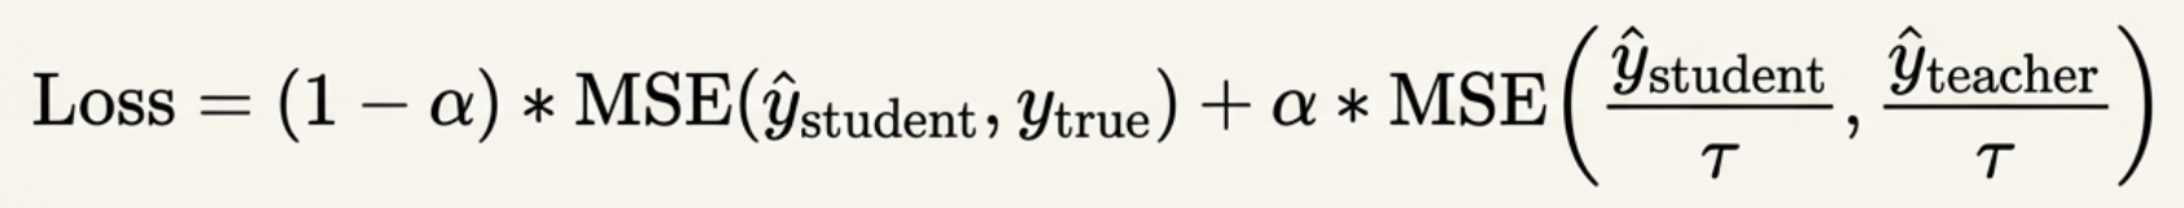

Loss_student = constrained_weighted_mse_loss(y_true, y_pred) \
               + alpha * MSE(y_pred / tau, y_teacher / tau)


In [22]:

# ==================== 12.2. Student model ====================
# Distillation Loss for Student(image-only)
def distillation_loss(
    target_names,
    alpha=0.4,      # weight for teacher loss  alpha ∈ {0.2, 0.3, 0.5}  
    tau=1.0,        # temperature for distillation
):
    """Create a distillation loss combining GT and teacher predictions.

    Args:
        alpha: Weight of the teacher term in the final loss
            (0 → pure GT, 1 → pure teacher).
        tau: Temperature used to soften student/teacher outputs.
        n_targets: Number of target dimensions.

    Returns:
        Callable: Loss function `loss_fn(y_true_concat, y_pred)` where
        `y_true_concat = [y_gt, y_teacher]` along the last dimension.
        
    Note:
    mse_distill ≈ (1 / tau**2) * MSE(y_pred, y_teacher)
    So the effective weights are:
    Loss ≈ (1 - alpha) * L_gt + alpha / (tau**2) * L_teacher
    """
    
    n_targets = len(target_names)
    loss_weights = tf.constant(get_loss_weights(target_names), tf.float32)

    def loss_fn(y_true_concat, y_pred):
        # Split ground truth and teacher predictions
        y_true    = y_true_concat[:, :n_targets]
        y_teacher = y_true_concat[:, n_targets:]
        
        # Student vs GT weighted MSE
        err_gt = tf.square(y_pred - y_true)
        mse_gt = tf.reduce_mean(err_gt * loss_weights, axis=-1) 
        
        # Student vs teacher weighted MSE (with temperature)
        y_pred_t    = y_pred    / tau
        y_teacher_t = y_teacher / tau
        err_distill = tf.square(y_pred_t - y_teacher_t)
        mse_distill = tf.reduce_mean(err_distill * loss_weights, axis=-1) 
        
        # Total loss = (1 - alpha) * GT + alpha * teacher
        return (1.0 - alpha) * mse_gt + alpha * mse_distill
    
    loss_fn.__name__ = "distillation_loss"
    return loss_fn

In [23]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
def teacher_only_loss(target_names):
    n_targets = len(target_names)
    loss_weights = tf.constant(get_loss_weights(target_names), tf.float32)

    def loss_fn(y_true_concat, y_pred):
        y_teacher = y_true_concat[:, n_targets:]
        err = tf.square(y_pred - y_teacher)
        mse = tf.reduce_mean(err * loss_weights, axis=-1)
        return mse

    loss_fn.__name__ = "teacher_only_loss"
    return loss_fn
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

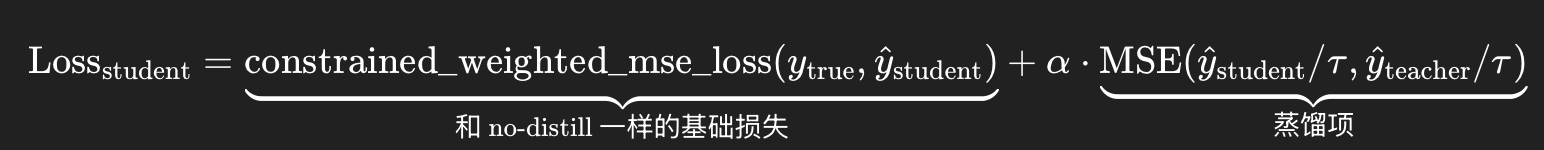

In [24]:
def distillation_with_constraints(
    target_names,
    alpha=0.4,
    tau=1.0,
    lambda_total=0.1,
    lambda_gdm=0.1,
    max_err=200.0,
):
    """
    y_true_concat = [y_true, y_teacher]  
    y_pred        = y_student

    Loss = constrained_weighted_mse_loss(y_true, y_pred)
           + alpha * MSE( y_pred/tau, y_teacher/tau )
    """
    base_loss = constrained_weighted_mse_loss(
        target_names=target_names,
        lambda_total=lambda_total,
        lambda_gdm=lambda_gdm,
        max_err=max_err,
    )

    n_targets = len(target_names)
    loss_weights = tf.constant(get_loss_weights(target_names), tf.float32)

    def loss_fn(y_true_concat, y_pred):
        y_true    = y_true_concat[:, :n_targets]
        y_teacher = y_true_concat[:, n_targets:]

        # ① 
        base = base_loss(y_true, y_pred) # scalar

        # ② Student vs Teacher
        y_pred_t    = y_pred    / tau
        y_teacher_t = y_teacher / tau
        err = tf.square(y_pred_t - y_teacher_t) * loss_weights  # (B, T)
        mse_distill_per_sample = tf.reduce_mean(err, axis=-1)   # (B,)
        mse_distill = tf.reduce_mean(mse_distill_per_sample)    # scalar

        return base + alpha * mse_distill
    
    loss_fn.__name__ = "distillation_with_constraints"
    return loss_fn

-------------------------------------------------------------------------------------

In [25]:


from networkx import constraint

def biomass_student_from_baseline(
    image_size_h: int = CFG.image_size_h, 
    image_size_w: int = CFG.image_size_w, 
    target_names: list | None = None,
    baseline_weights_path: str | None = None,
    distill_alpha: float = 0.4,
    distill_tau: float = 1.0, 
    use_distill_loss: bool = True,
    distill_mode="none",
) -> tf.keras.Model:
    use_kd = use_distill_loss and (distill_mode != "none")
    
    def make_distill_metrics(target_names):
        n_targets = len(target_names)
        loss_weights = tf.constant(get_loss_weights(target_names), tf.float32)

        def mse_gt_metric(y_true_concat, y_pred):
            y_true = y_true_concat[:, :n_targets]
            err = tf.square(y_pred - y_true)

            return tf.reduce_mean(err * loss_weights)

        mse_gt_metric.__name__ = "mse_gt"
   
        def mse_teacher_metric(y_true_concat, y_pred):
            y_teacher = y_true_concat[:, n_targets:]
            err = tf.square(y_pred - y_teacher)
            return tf.reduce_mean(err * loss_weights)

        mse_teacher_metric.__name__ = "mse_teacher"
        return [mse_gt_metric, mse_teacher_metric]

    if target_names is None:
        target_names = TRAIN_TARGETS
    n_targets = len(target_names)

    # 1) Student backbone (image-only)
    backbone = build_image_backbone(image_size_h, image_size_w, name="ImageBackboneStudent")
    img_inputs = layers.Input(shape=(image_size_h, image_size_w, 3), name="image")
    x = backbone(img_inputs)

    # 2) Regression head (can mirror baseline or be slightly deeper)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    # Optionally add another layer:
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(
        n_targets,
        activation="softplus",
        name="biomass",
        dtype="float32",
    )(x)

    model = models.Model(
        inputs=img_inputs, outputs=outputs, name="StudentFromBaseline"
    )

    # 3) If baseline weights are provided, copy its backbone weights
    if baseline_weights_path is not None:
        print(f"[Student] load baseline backbone from {baseline_weights_path}")
        # Create a temporary baseline model to load weights into
        baseline_tmp = biomass_conv_baseline(
            image_size_h=image_size_h,
            image_size_w=image_size_w,
            target_names=target_names,
            lambda_aux_cont=0.3,  
            lambda_aux_cat=0.3,  
        )
        baseline_tmp.load_weights(baseline_weights_path)

        # Extract backbones
        baseline_backbone = baseline_tmp.get_layer("ImageBackbone")
        student_backbone  = model.get_layer("ImageBackboneStudent")

         # Copy CNN backbone parameters
        student_backbone.set_weights(baseline_backbone.get_weights())
        print("[Student] backbone weights copied from baseline")

        # Free the temporary model
        del baseline_tmp

    # 4) Compile model
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Loss function selection
    if distill_mode == "none": # Student without KD / image-only/ GT-only(gram label + penalty + aux)
        loss_fn = constrained_weighted_mse_loss(
            target_names=target_names,
            lambda_total=0.1,   
            lambda_gdm=0.1,
            max_err=200.0,
        )
        print(f"[Student] mode='none' -> {loss_fn.__name__} (GT only)")
    
    elif distill_mode == "teacher_only": #  teacher prediction (image+meta)
        loss_fn = teacher_only_loss(target_names=target_names)
        print(f"[Student] mode='teacher_only' -> {loss_fn.__name__}")
        
    elif distill_mode == "mix": # Standard KD (GT + Teacher)
        loss_fn = distillation_loss(
            alpha=distill_alpha,
            tau=distill_tau,  
            target_names=target_names,
        )
        print(f"[Student] mode='mix' -> {loss_fn.__name__} "
              f"(α={distill_alpha}, τ={distill_tau})")
    
    elif distill_mode == "constraint": # Constrained KD (GT + Teacher + Penalty)
        loss_fn = distillation_with_constraints(
            target_names=target_names,
            alpha=distill_alpha,
            tau=distill_tau,
            lambda_total=0.1,
            lambda_gdm=0.1,
            max_err=200.0,
        )
        print(f"[Student] mode='constraint' -> {loss_fn.__name__} "
              f"(α={distill_alpha}, τ={distill_tau})")
    
    else:
        raise ValueError(
            f"Invalid distill_mode='{distill_mode}'. "
            f"Expected one of: 'none', 'mix', 'teacher_only', 'constraint'"
        )

    metrics = make_mae_metrics(target_names)
    if use_distill_loss:
        metrics += make_distill_metrics(target_names)

    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss=loss_fn,
        metrics=metrics,
    )
    
    return model

--------------------------------------

In [26]:

def train_one_fold_student_distill(
    fold,
    teacher_model,
    alpha=0.4,
    tau=3.0,
    target_list=None,
    model_fn=biomass_student_from_baseline,
    use_distill_loss=True,
    **model_kwargs,
):
    """Train a distilled student for one fold using a fixed teacher model.
    Args:
        fold: Fold index used as validation split.
        teacher_model: Trained teacher model (image + metadata) used to
            generate soft labels.
        alpha: Distillation weight (teacher term) passed to the loss.
        tau: Distillation temperature passed to the loss.
        target_list: List of target column names; if None, defaults to TRAIN_TARGETS.
        model_fn: Function that builds the student model.
        **model_kwargs: Extra keyword arguments forwarded to `model_fn`.

    Returns:
        tuple: (best_val_mae, student_model, history, val_ds, w_r2)
    """
    
    distill_mode = model_kwargs.get("distill_mode", "none")
    use_kd = use_distill_loss and (distill_mode != "none")

    print(
        f"\n===== [Student Distill] Fold {fold} (alpha={alpha}, tau={tau}, "
        f"use_kd={use_kd}, distill_mode={distill_mode}) ====="
    )
    
    # 1) Build data module and collect all data: imgs_all, y_gt_all, meta_cont_all, meta_cat_all
    dm = BiomassImgDataModule(
        fold=fold,
        target_list=target_list,
        include_meta=True,  # True: need meta_cont/meta_cat feed to Teacher; Student is still image-only
        aux_targets=False, 
    )
    if target_list is None:
        target_list = TRAIN_TARGETS  
    
    imgs_all = dm.make_arrays()          # (N, H, W, 3)
    y_gt_all = dm.y                     # (N, T), 5 biomass

    meta_cont_all = dm.df[dm.meta_cols_cont].astype("float32").values
    meta_cat_all  = dm.df[dm.meta_cols_cat ].astype("int32").values
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # 2) Teacher predictions for all samples 
    if use_kd:
        if use_distill_loss and distill_mode != "none":
            if teacher_model is None:
                raise ValueError("use_distill_loss=True but teacher_model is None")

            x_all = {
                "image":     imgs_all,
                "meta_cont": meta_cont_all,
                "meta_cat":  meta_cat_all,
            }

            teacher_preds_all = teacher_model.predict(
                x_all,
                batch_size=CFG.batch_size,
                verbose=1,
            )  # shape (N, T) or similar

            # 3) Concatenate GT + teacher predictions: y_true_concat = [y_gt, y_teacher] (KD)
            y_concat_all = np.concatenate([y_gt_all, teacher_preds_all], axis=1)  # (N, 2T)
    else:
        # No KD: only ground truth targets
        teacher_preds_all = None
        y_concat_all = y_gt_all

        
    print("[Debug] use_kd              =", use_kd)
    print("[Debug] y_gt_all.shape      =", y_gt_all.shape)
    print("[Debug] y_concat_all.shape  =", y_concat_all.shape)

    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    if teacher_preds_all is not None:
        print("[Debug] teacher_preds_all.shape =", teacher_preds_all.shape)
        print("[Debug] first sample GT:", y_gt_all[0])
        print("[Debug] first sample teacher:", teacher_preds_all[0])
        print("[Debug] y_concat_all.shape =", y_concat_all.shape)     # (N, 2T)

        val_mask = (dm.df["fold"] == fold).values
        va_idx = np.where(val_mask)[0]

        val_df = dm.df[val_mask].reset_index(drop=True)

        teacher_val = teacher_preds_all[va_idx]

        w_r2_teacher_for_KD, _, _ = eval_weighted_r2_in_gram(
            val_df=val_df,
            y_pred_default=teacher_val,
            model_name=f"Teacher_for_KD_fold{fold}",
            fold=fold,
        )
        
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # 4) Train / Val split
    val_mask = (dm.df["fold"] == fold).values
    tr_idx = np.where(~val_mask)[0]
    va_idx = np.where(val_mask)[0]

    print(f"[Student] Fold {fold} Train: {len(tr_idx)} | Val: {len(va_idx)}")
    
    # base on use_distill_loss to decide y_true
    if use_distill_loss:
        y_train = y_concat_all[tr_idx]   # (N_tr, 2T) -> distillation_loss / distillation_with_constraints
        y_val   = y_concat_all[va_idx]
    else:
        y_train = y_gt_all[tr_idx]       # (N_tr, T)   -> constrained_weighted_mse_loss
        y_val   = y_gt_all[va_idx]

    # 5) datasets
    train_ds = tf.data.Dataset.from_tensor_slices(
        (imgs_all[tr_idx], y_train)
    )
    val_ds = tf.data.Dataset.from_tensor_slices(
        (imgs_all[va_idx], y_val)
    )

    train_ds = (
        train_ds
        .map(tfdata_augmentor, num_parallel_calls=1)
        .shuffle(1024, seed=CFG.seed, reshuffle_each_iteration=True)
        .batch(CFG.batch_size)
        .prefetch(1)
    )
    val_ds = (
        val_ds
        .map(tfdata_clip, num_parallel_calls=1)
        .batch(CFG.batch_size)
        .prefetch(1)
    )

    # 6) Build student-from-baseline + distillation loss (loss_fn)
    mode = "log1p" if CFG.use_log1p else "gram"
    baseline_ckpt = f"./ckpt/baseline_{mode}_fold{fold}.weights.h5"

    student_model = model_fn(
        image_size_h=CFG.image_size_h,
        image_size_w=CFG.image_size_w,
        target_names=target_list,
        baseline_weights_path=baseline_ckpt,
        use_distill_loss=use_kd,
        distill_alpha=alpha, # teacher weight in distillation loss
        distill_tau=tau,      # biomass_student_from_baseline 
        **model_kwargs,
    )

    # 6) callbacks
    callbacks_list = build_callbacks(monitor="val_mae_all", mode="min")

    # 7) train
    history = student_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CFG.epochs,
        callbacks=callbacks_list,
        verbose=1,
    )

    best_val_mae = min(history.history["val_mae_all"])
    print(f"[Student] Fold {fold} best val_mae_all = {best_val_mae:.3f}")

    # 8) Evaluate in gram space
    val_df, x_val = build_val_inputs(
        dm=dm,
        fold=fold,
        include_meta=False,   # student uses image only for inference
    )
    y_pred_default = student_model.predict(x_val, batch_size=CFG.batch_size)

    w_r2, pred_df, true_df = eval_weighted_r2_in_gram(
        val_df=val_df,
        y_pred_default=y_pred_default,
        model_name="Student",
        fold=fold,
        # target_list=target_list,
    )

    return best_val_mae, student_model, history, val_ds, w_r2


In [27]:

# ====== Train model: Distilled Student (image only)(gram) ======
set_label_mode(False)  # Set label mode to "gram"
# set_label_mode(True)  # Set label mode to "log1p"

teacher_only_results_gram = {}
teacher_only_fold_maes_gram = []
teacher_only_fold_r2_gram = []

set_seed(CFG.seed)

for f in range(CFG.n_folds):  
# for f in [1]:  
    student_mae, student_model, student_hist, student_valds, student_r2 = \
        train_one_fold_student_distill(
            fold=f,
            teacher_model=teacher_models_gram[f],   # trained teacher fisrt
            alpha=1.0,  # only teacher loss
            tau=1.0,
            distill_mode="teacher_only",
            use_distill_loss=True,  # only teacher loss
        )
    teacher_only_results_gram[f] = (student_mae, student_r2)
    teacher_only_fold_maes_gram.append(student_mae)
    teacher_only_fold_r2_gram.append(student_r2)

print("\n===== [teacher_only] 5-fold CV summary =====")
print("MAE per fold:", np.round(teacher_only_fold_maes_gram, 3))
print("R2  per fold:", np.round(teacher_only_fold_r2_gram, 3))
print("mean R2 =", np.mean(teacher_only_fold_r2_gram))


[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== [Student Distill] Fold 0 (alpha=1.0, tau=1.0, use_kd=True, distill_mode=teacher_only) =====
[Info] NaN counts in continuous meta before fillna:
 Pre_GSHH_NDVI      0
Height_Ave_cm      0
year               0
month_sin          0
month_cos          0
day_of_year_sin    0
day_of_year_cos    0
dtype: int64
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step
[Debug] use_kd              = True
[Debug] y_gt_all.shape      = (357, 5)
[Debug] y_concat_all.shape  = (357, 10)
[Debug] teacher_preds_all.shape = (357, 5)
[Debug] first sample GT: [16.2751 31.9984  0.     16.275  48.2735]
[Debug] first sample teacher: [17.83734  11.235123  6.677492 23.456577 35.904167]
[Debug] y_concat_all.shape = (357, 10)
[Teacher_for_KD_fold0] Fold 0 Kaggle-style weighted R2 = 0.5039
[Student] Fold 0 Train: 285 | Val: 72
[Student] load baseline backbone from

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 936ms/step - loss: 246.3126 - mae__dry__clover_g: 6.8351 - mae__dry__dead_g: 11.3847 - mae__dry__green_g: 26.3265 - mae__dry__total_g: 43.3350 - mae_all: 24.2385 - mae_gdm_g: 33.3114 - mse_gt: 370.4735 - mse_teacher: 246.4126 - val_loss: 233.8496 - val_mae__dry__clover_g: 5.5797 - val_mae__dry__dead_g: 13.3357 - val_mae__dry__green_g: 25.1712 - val_mae__dry__total_g: 41.9369 - val_mae_all: 23.3319 - val_mae_gdm_g: 30.6360 - val_mse_gt: 341.1096 - val_mse_teacher: 233.8496 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 930ms/step - loss: 220.8721 - mae__dry__clover_g: 6.7429 - mae__dry__dead_g: 11.4682 - mae__dry__green_g: 26.3226 - mae__dry__total_g: 40.5380 - mae_all: 23.5883 - mae_gdm_g: 32.8697 - mse_gt: 341.7652 - mse_teacher: 220.6844 - val_loss: 205.8250 - val_mae__dry__clover_g: 5.6026 - val_mae__dry__dead_g: 13.4087 - val_mae__dry__green_g: 25.1602 - val_mae__dry__total_g: 38.7068 - val_mae_all: 22.5859 - val_mae_gdm_g: 30.0

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 946ms/step - loss: 280.7431 - mae__dry__clover_g: 6.3608 - mae__dry__dead_g: 11.1693 - mae__dry__green_g: 26.3800 - mae__dry__total_g: 44.6921 - mae_all: 24.2261 - mae_gdm_g: 32.5281 - mse_gt: 386.1169 - mse_teacher: 279.9992 - val_loss: 267.2552 - val_mae__dry__clover_g: 7.0971 - val_mae__dry__dead_g: 10.5447 - val_mae__dry__green_g: 25.4418 - val_mae__dry__total_g: 43.2020 - val_mae_all: 23.6529 - val_mae_gdm_g: 31.9792 - val_mse_gt: 342.7642 - val_mse_teacher: 267.2552 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 934ms/step - loss: 265.8374 - mae__dry__clover_g: 6.3675 - mae__dry__dead_g: 10.7940 - mae__dry__green_g: 26.4705 - mae__dry__total_g: 43.2476 - mae_all: 23.7712 - mae_gdm_g: 31.9764 - mse_gt: 371.0561 - mse_teacher: 265.5734 - val_loss: 235.1707 - val_mae__dry__clover_g: 7.1026 - val_mae__dry__dead_g: 9.9212 - val_mae__dry__green_g: 25.5111 - val_mae__dry__total_g: 40.0425 - val_mae_all: 22.6386 - val_mae_gdm_g: 30.61

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 954ms/step - loss: 212.8292 - mae__dry__clover_g: 6.2500 - mae__dry__dead_g: 12.0889 - mae__dry__green_g: 25.2131 - mae__dry__total_g: 43.3307 - mae_all: 23.7465 - mae_gdm_g: 31.8497 - mse_gt: 357.7704 - mse_teacher: 212.9453 - val_loss: 230.8535 - val_mae__dry__clover_g: 7.5384 - val_mae__dry__dead_g: 9.8330 - val_mae__dry__green_g: 28.0761 - val_mae__dry__total_g: 43.6791 - val_mae_all: 25.0085 - val_mae_gdm_g: 35.9160 - val_mse_gt: 413.6557 - val_mse_teacher: 233.1774 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 945ms/step - loss: 190.2937 - mae__dry__clover_g: 6.2253 - mae__dry__dead_g: 12.0839 - mae__dry__green_g: 24.6554 - mae__dry__total_g: 40.3942 - mae_all: 23.0056 - mae_gdm_g: 31.6693 - mse_gt: 329.1477 - mse_teacher: 190.1887 - val_loss: 187.9233 - val_mae__dry__clover_g: 7.5580 - val_mae__dry__dead_g: 10.0201 - val_mae__dry__green_g: 27.2683 - val_mae__dry__total_g: 38.4608 - val_mae_all: 23.7911 - val_mae_gdm_g: 35.64

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 955ms/step - loss: 207.9364 - mae__dry__clover_g: 6.4359 - mae__dry__dead_g: 10.9553 - mae__dry__green_g: 26.4253 - mae__dry__total_g: 44.1949 - mae_all: 24.1898 - mae_gdm_g: 32.9380 - mse_gt: 382.3324 - mse_teacher: 208.1379 - val_loss: 193.9823 - val_mae__dry__clover_g: 7.0955 - val_mae__dry__dead_g: 12.9595 - val_mae__dry__green_g: 23.7382 - val_mae__dry__total_g: 42.5474 - val_mae_all: 23.4969 - val_mae_gdm_g: 31.1442 - val_mse_gt: 330.7954 - val_mse_teacher: 192.7288 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 955ms/step - loss: 196.1868 - mae__dry__clover_g: 6.3916 - mae__dry__dead_g: 10.9568 - mae__dry__green_g: 26.4373 - mae__dry__total_g: 42.5343 - mae_all: 23.7962 - mae_gdm_g: 32.6612 - mse_gt: 366.8578 - mse_teacher: 195.4718 - val_loss: 161.7095 - val_mae__dry__clover_g: 6.9827 - val_mae__dry__dead_g: 13.1177 - val_mae__dry__green_g: 23.8156 - val_mae__dry__total_g: 37.9011 - val_mae_all: 22.5016 - val_mae_gdm_g: 30.6

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 976ms/step - loss: 339.5770 - mae__dry__clover_g: 6.8282 - mae__dry__dead_g: 11.6086 - mae__dry__green_g: 25.6717 - mae__dry__total_g: 44.2362 - mae_all: 24.1305 - mae_gdm_g: 32.3080 - mse_gt: 369.1032 - mse_teacher: 340.2726 - val_loss: 316.3216 - val_mae__dry__clover_g: 5.4076 - val_mae__dry__dead_g: 11.4493 - val_mae__dry__green_g: 27.1589 - val_mae__dry__total_g: 43.7410 - val_mae_all: 24.0826 - val_mae_gdm_g: 32.6561 - val_mse_gt: 395.8856 - val_mse_teacher: 315.3177 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 947ms/step - loss: 319.5677 - mae__dry__clover_g: 6.8485 - mae__dry__dead_g: 11.9685 - mae__dry__green_g: 25.6470 - mae__dry__total_g: 42.1186 - mae_all: 23.7196 - mae_gdm_g: 32.0154 - mse_gt: 350.1707 - mse_teacher: 318.8813 - val_loss: 288.4340 - val_mae__dry__clover_g: 5.4471 - val_mae__dry__dead_g: 11.5972 - val_mae__dry__green_g: 27.2240 - val_mae__dry__total_g: 40.7495 - val_mae_all: 23.4898 - val_mae_gdm_g: 32.4

In [28]:

# ====== Train model: Distilled Student (image only)(gram) ======
set_label_mode(False)  # Set label mode to "gram"
# set_label_mode(True)  # Set label mode to "log1p"

student_noKD_results_gram = {}
student_noKD_fold_maes_gram = []
student_noKD_fold_r2_gram = []

set_seed(CFG.seed)

for f in range(CFG.n_folds):
# for f in [1]:  
    student_mae, student_model, student_hist, student_valds, student_r2 = \
        train_one_fold_student_distill(
            fold=f,
            # teacher_model=teacher_models_gram[f],   # trained teacher fisrt
            teacher_model=None,     # no teacher
            alpha=0.0,
            tau=1.0,
            use_distill_loss=False, 
            distill_mode="none",  
        )
    student_noKD_results_gram[f] = (student_mae, student_r2)
    student_noKD_fold_maes_gram.append(student_mae)
    student_noKD_fold_r2_gram.append(student_r2)

print("\n===== [Student_noKD] 5-fold CV summary =====")
print("MAE per fold:", np.round(student_noKD_fold_maes_gram, 3))
print("R2  per fold:", np.round(student_noKD_fold_r2_gram, 3))
print("mean R2 =", np.mean(student_noKD_fold_r2_gram))


[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== [Student Distill] Fold 0 (alpha=0.0, tau=1.0, use_kd=False, distill_mode=none) =====
[Info] NaN counts in continuous meta before fillna:
 Pre_GSHH_NDVI      0
Height_Ave_cm      0
year               0
month_sin          0
month_cos          0
day_of_year_sin    0
day_of_year_cos    0
dtype: int64
[Debug] use_kd              = False
[Debug] y_gt_all.shape      = (357, 5)
[Debug] y_concat_all.shape  = (357, 5)
[Student] Fold 0 Train: 285 | Val: 72
[Student] load baseline backbone from ./ckpt/baseline_gram_fold0.weights.h5
[biomass_conv_baseline] using loss = multitask_biomass_aux_loss_with_constraints
[Student] backbone weights copied from baseline
[Student] mode='none' -> constrained_weighted_mse_loss (GT only)
Epoch 1/10


/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 938ms/step - loss: 371.7372 - mae__dry__clover_g: 6.8311 - mae__dry__dead_g: 11.3799 - mae__dry__green_g: 26.3399 - mae__dry__total_g: 43.3729 - mae_all: 24.2477 - mae_gdm_g: 33.3149 - val_loss: 342.1629 - val_mae__dry__clover_g: 5.5661 - val_mae__dry__dead_g: 13.3273 - val_mae__dry__green_g: 25.1861 - val_mae__dry__total_g: 42.0090 - val_mae_all: 23.3472 - val_mae_gdm_g: 30.6478 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 932ms/step - loss: 345.7018 - mae__dry__clover_g: 6.7324 - mae__dry__dead_g: 11.4592 - mae__dry__green_g: 26.3503 - mae__dry__total_g: 40.8170 - mae_all: 23.6523 - mae_gdm_g: 32.9027 - val_loss: 314.9196 - val_mae__dry__clover_g: 5.6372 - val_mae__dry__dead_g: 13.4056 - val_mae__dry__green_g: 25.1759 - val_mae__dry__total_g: 38.8681 - val_mae_all: 22.6284 - val_mae_gdm_g: 30.0552 - learning_rate: 1.0000e-04
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 937ms/step - loss: 309.9000 - mae__dry__clover_g: 6.9538 - mae_

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 936ms/step - loss: 387.0681 - mae__dry__clover_g: 6.3602 - mae__dry__dead_g: 11.2125 - mae__dry__green_g: 26.3871 - mae__dry__total_g: 44.7069 - mae_all: 24.2416 - mae_gdm_g: 32.5416 - val_loss: 343.1837 - val_mae__dry__clover_g: 7.0924 - val_mae__dry__dead_g: 10.5982 - val_mae__dry__green_g: 25.4560 - val_mae__dry__total_g: 43.2155 - val_mae_all: 23.6718 - val_mae_gdm_g: 31.9971 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 968ms/step - loss: 371.7740 - mae__dry__clover_g: 6.3645 - mae__dry__dead_g: 10.9098 - mae__dry__green_g: 26.4825 - mae__dry__total_g: 43.3611 - mae_all: 23.8272 - mae_gdm_g: 32.0182 - val_loss: 309.6803 - val_mae__dry__clover_g: 7.0911 - val_mae__dry__dead_g: 9.9937 - val_mae__dry__green_g: 25.5235 - val_mae__dry__total_g: 40.0446 - val_mae_all: 22.6500 - val_mae_gdm_g: 30.5974 - learning_rate: 1.0000e-04
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 945ms/step - loss: 341.5183 - mae__dry__clover_g: 6.4953 - mae__

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 949ms/step - loss: 357.8947 - mae__dry__clover_g: 6.2518 - mae__dry__dead_g: 12.0971 - mae__dry__green_g: 25.2310 - mae__dry__total_g: 43.3523 - mae_all: 23.7571 - mae_gdm_g: 31.8536 - val_loss: 406.1370 - val_mae__dry__clover_g: 7.5456 - val_mae__dry__dead_g: 9.8486 - val_mae__dry__green_g: 28.0945 - val_mae__dry__total_g: 43.6201 - val_mae_all: 25.0101 - val_mae_gdm_g: 35.9417 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 948ms/step - loss: 332.7687 - mae__dry__clover_g: 6.2322 - mae__dry__dead_g: 12.0857 - mae__dry__green_g: 24.7313 - mae__dry__total_g: 40.5453 - mae_all: 23.0517 - mae_gdm_g: 31.6642 - val_loss: 359.3481 - val_mae__dry__clover_g: 7.5706 - val_mae__dry__dead_g: 10.0008 - val_mae__dry__green_g: 27.3519 - val_mae__dry__total_g: 38.5922 - val_mae_all: 23.8292 - val_mae_gdm_g: 35.6304 - learning_rate: 1.0000e-04
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 941ms/step - loss: 299.0381 - mae__dry__clover_g: 6.2964 - mae__

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 944ms/step - loss: 383.5459 - mae__dry__clover_g: 6.4352 - mae__dry__dead_g: 10.9665 - mae__dry__green_g: 26.4482 - mae__dry__total_g: 44.2141 - mae_all: 24.2006 - mae_gdm_g: 32.9392 - val_loss: 335.9802 - val_mae__dry__clover_g: 7.1196 - val_mae__dry__dead_g: 12.9642 - val_mae__dry__green_g: 23.7795 - val_mae__dry__total_g: 42.7312 - val_mae_all: 23.5492 - val_mae_gdm_g: 31.1513 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 945ms/step - loss: 370.0847 - mae__dry__clover_g: 6.3973 - mae__dry__dead_g: 10.9672 - mae__dry__green_g: 26.4819 - mae__dry__total_g: 42.6433 - mae_all: 23.8298 - mae_gdm_g: 32.6593 - val_loss: 301.9723 - val_mae__dry__clover_g: 7.0150 - val_mae__dry__dead_g: 13.1104 - val_mae__dry__green_g: 23.8855 - val_mae__dry__total_g: 38.6576 - val_mae_all: 22.6757 - val_mae_gdm_g: 30.7098 - learning_rate: 1.0000e-04
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 947ms/step - loss: 347.1230 - mae__dry__clover_g: 6.3533 - mae_

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 369.3716 - mae__dry__clover_g: 6.8310 - mae__dry__dead_g: 11.6326 - mae__dry__green_g: 25.6918 - mae__dry__total_g: 44.2445 - mae_all: 24.1444 - mae_gdm_g: 32.3221 - val_loss: 396.6036 - val_mae__dry__clover_g: 5.4152 - val_mae__dry__dead_g: 11.4543 - val_mae__dry__green_g: 27.1950 - val_mae__dry__total_g: 43.7596 - val_mae_all: 24.0967 - val_mae_gdm_g: 32.6593 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 957ms/step - loss: 353.0582 - mae__dry__clover_g: 6.8499 - mae__dry__dead_g: 11.9751 - mae__dry__green_g: 25.6786 - mae__dry__total_g: 42.3300 - mae_all: 23.7791 - mae_gdm_g: 32.0620 - val_loss: 373.9375 - val_mae__dry__clover_g: 5.4535 - val_mae__dry__dead_g: 11.5903 - val_mae__dry__green_g: 27.2528 - val_mae__dry__total_g: 41.1976 - val_mae_all: 23.5912 - val_mae_gdm_g: 32.4617 - learning_rate: 1.0000e-04
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 951ms/step - loss: 328.5963 - mae__dry__clover_g: 6.8414 - mae__dr

In [29]:


# ====== Train model: Distilled Student (image only)(gram) ======
set_label_mode(False)  # Set label mode to "gram"
# set_label_mode(True)  # Set label mode to "log1p"

student_results_gram = {}
student_fold_maes_gram = []
student_fold_r2_gram = []

student_models_gram = [] # 👈

set_seed(CFG.seed)

for f in range(CFG.n_folds):
# for f in [1]:  
    
    student_mae, student_model, student_hist, student_valds, student_r2 = \
        train_one_fold_student_distill(
            fold=f,
            teacher_model=teacher_models_gram[f],   # trained teacher fisrt
            alpha=0.55,
            tau=1.0,
            distill_mode="mix", 
            use_distill_loss=True,   
        )
    student_results_gram[f] = (student_mae, student_r2)
    student_fold_maes_gram.append(student_mae)
    student_fold_r2_gram.append(student_r2)
    student_models_gram.append(student_model) # 👈
    
    weights_path = f"./ckpt/student_distill_gram_fold{f}.weights.h5" # 👈
    student_model.save_weights(weights_path) # 👈
    print(f"[Student Distill] fold {f} weights saved to {weights_path}") # 👈

print("\n===== [Student Distill] 5-fold CV summary =====")
print("MAE per fold:", np.round(student_fold_maes_gram, 3))
print("R2  per fold:", np.round(student_fold_r2_gram, 3))
print("mean R2 =", np.mean(student_fold_r2_gram))


[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== [Student Distill] Fold 0 (alpha=0.55, tau=1.0, use_kd=True, distill_mode=mix) =====
[Info] NaN counts in continuous meta before fillna:
 Pre_GSHH_NDVI      0
Height_Ave_cm      0
year               0
month_sin          0
month_cos          0
day_of_year_sin    0
day_of_year_cos    0
dtype: int64
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step
[Debug] use_kd              = True
[Debug] y_gt_all.shape      = (357, 5)
[Debug] y_concat_all.shape  = (357, 10)
[Debug] teacher_preds_all.shape = (357, 5)
[Debug] first sample GT: [16.2751 31.9984  0.     16.275  48.2735]
[Debug] first sample teacher: [17.83734  11.235123  6.677492 23.456577 35.904167]
[Debug] y_concat_all.shape = (357, 10)
[Teacher_for_KD_fold0] Fold 0 Kaggle-style weighted R2 = 0.5039
[Student] Fold 0 Train: 285 | Val: 72
[Student] load baseline backbone from ./ckpt/

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 944ms/step - loss: 302.5328 - mae__dry__clover_g: 6.8348 - mae__dry__dead_g: 11.3839 - mae__dry__green_g: 26.3277 - mae__dry__total_g: 43.3455 - mae_all: 24.2407 - mae_gdm_g: 33.3112 - mse_gt: 370.5786 - mse_teacher: 246.5076 - val_loss: 282.2766 - val_mae__dry__clover_g: 5.5807 - val_mae__dry__dead_g: 13.3339 - val_mae__dry__green_g: 25.1689 - val_mae__dry__total_g: 41.9561 - val_mae_all: 23.3357 - val_mae_gdm_g: 30.6389 - val_mse_gt: 341.2615 - val_mse_teacher: 234.0162 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 958ms/step - loss: 275.9615 - mae__dry__clover_g: 6.7441 - mae__dry__dead_g: 11.4663 - mae__dry__green_g: 26.3239 - mae__dry__total_g: 40.6185 - mae_all: 23.6075 - mae_gdm_g: 32.8849 - mse_gt: 342.5051 - mse_teacher: 221.3587 - val_loss: 252.7686 - val_mae__dry__clover_g: 5.6230 - val_mae__dry__dead_g: 13.4113 - val_mae__dry__green_g: 25.1639 - val_mae__dry__total_g: 38.6094 - val_mae_all: 22.5733 - val_mae_gdm_g: 30.0

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 960ms/step - loss: 328.3953 - mae__dry__clover_g: 6.3599 - mae__dry__dead_g: 11.1715 - mae__dry__green_g: 26.3821 - mae__dry__total_g: 44.6977 - mae_all: 24.2278 - mae_gdm_g: 32.5277 - mse_gt: 386.1766 - mse_teacher: 280.0556 - val_loss: 301.1907 - val_mae__dry__clover_g: 7.0962 - val_mae__dry__dead_g: 10.5325 - val_mae__dry__green_g: 25.4512 - val_mae__dry__total_g: 43.1962 - val_mae_all: 23.6500 - val_mae_gdm_g: 31.9740 - val_mse_gt: 342.7120 - val_mse_teacher: 267.2186 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 941ms/step - loss: 313.1247 - mae__dry__clover_g: 6.3652 - mae__dry__dead_g: 10.7980 - mae__dry__green_g: 26.4799 - mae__dry__total_g: 43.2801 - mae_all: 23.7794 - mae_gdm_g: 31.9736 - mse_gt: 371.3210 - mse_teacher: 265.8407 - val_loss: 267.2453 - val_mae__dry__clover_g: 7.0973 - val_mae__dry__dead_g: 9.8852 - val_mae__dry__green_g: 25.5290 - val_mae__dry__total_g: 39.9206 - val_mae_all: 22.5945 - val_mae_gdm_g: 30.54

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 951ms/step - loss: 277.9563 - mae__dry__clover_g: 6.2500 - mae__dry__dead_g: 12.0900 - mae__dry__green_g: 25.2138 - mae__dry__total_g: 43.3366 - mae_all: 23.7485 - mae_gdm_g: 31.8523 - mse_gt: 357.8441 - mse_teacher: 213.0103 - val_loss: 309.5557 - val_mae__dry__clover_g: 7.5382 - val_mae__dry__dead_g: 9.8377 - val_mae__dry__green_g: 28.0724 - val_mae__dry__total_g: 43.6464 - val_mae_all: 25.0058 - val_mae_gdm_g: 35.9343 - val_mse_gt: 413.5379 - val_mse_teacher: 233.0892 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 934ms/step - loss: 253.6310 - mae__dry__clover_g: 6.2256 - mae__dry__dead_g: 12.0871 - mae__dry__green_g: 24.6676 - mae__dry__total_g: 40.4183 - mae_all: 23.0153 - mae_gdm_g: 31.6776 - mse_gt: 329.3657 - mse_teacher: 190.4589 - val_loss: 261.8882 - val_mae__dry__clover_g: 7.5600 - val_mae__dry__dead_g: 10.0303 - val_mae__dry__green_g: 27.2792 - val_mae__dry__total_g: 38.3324 - val_mae_all: 23.7776 - val_mae_gdm_g: 35.68

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 959ms/step - loss: 286.7867 - mae__dry__clover_g: 6.4357 - mae__dry__dead_g: 10.9487 - mae__dry__green_g: 26.4269 - mae__dry__total_g: 44.2005 - mae_all: 24.1909 - mae_gdm_g: 32.9428 - mse_gt: 382.4108 - mse_teacher: 208.2190 - val_loss: 257.6125 - val_mae__dry__clover_g: 7.0945 - val_mae__dry__dead_g: 12.9539 - val_mae__dry__green_g: 23.7397 - val_mae__dry__total_g: 42.6179 - val_mae_all: 23.5106 - val_mae_gdm_g: 31.1472 - val_mse_gt: 331.4351 - val_mse_teacher: 193.2420 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 934ms/step - loss: 273.9443 - mae__dry__clover_g: 6.3901 - mae__dry__dead_g: 10.9426 - mae__dry__green_g: 26.4438 - mae__dry__total_g: 42.5462 - mae_all: 23.7985 - mae_gdm_g: 32.6696 - mse_gt: 367.0428 - mse_teacher: 195.7092 - val_loss: 222.6672 - val_mae__dry__clover_g: 6.9825 - val_mae__dry__dead_g: 13.1153 - val_mae__dry__green_g: 23.8395 - val_mae__dry__total_g: 38.1181 - val_mae_all: 22.5517 - val_mae_gdm_g: 30.7

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 740ms/step - loss: 352.8303 - mae__dry__clover_g: 6.8270 - mae__dry__dead_g: 11.6058 - mae__dry__green_g: 25.6716 - mae__dry__total_g: 44.2402 - mae_all: 24.1296 - mae_gdm_g: 32.3036 - mse_gt: 369.1325 - mse_teacher: 340.3082 - val_loss: 352.3527 - val_mae__dry__clover_g: 5.4074 - val_mae__dry__dead_g: 11.4490 - val_mae__dry__green_g: 27.1575 - val_mae__dry__total_g: 43.7475 - val_mae_all: 24.0809 - val_mae_gdm_g: 32.6434 - val_mse_gt: 395.9250 - val_mse_teacher: 315.3570 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 736ms/step - loss: 333.9218 - mae__dry__clover_g: 6.8479 - mae__dry__dead_g: 11.9660 - mae__dry__green_g: 25.6484 - mae__dry__total_g: 42.1753 - mae_all: 23.7310 - mae_gdm_g: 32.0174 - mse_gt: 350.7249 - mse_teacher: 319.4829 - val_loss: 325.5216 - val_mae__dry__clover_g: 5.4482 - val_mae__dry__dead_g: 11.5956 - val_mae__dry__green_g: 27.2271 - val_mae__dry__total_g: 40.8461 - val_mae_all: 23.5077 - val_mae_gdm_g: 32.4

===== [CNN Baseline - gram] CV summary ===== 15 epochs, 3 target
val_mae_all per fold: [10.121 11.914 10.549 10.01  10.141]
mean ± std = 10.54708251953125 ± 0.7075833822485404
weighted_r2 per fold: [ 0.304 -0.171  0.498  0.39   0.33 ]
basline_gram mean R2 = 0.2702052972636771

===== [CNN Baseline - gram] CV summary ===== 30 epochs, 5 target
val_mae_all per fold: [11.332 14.766 12.259 16.392 12.652]
mean ± std = 13.479974555969239 ± 1.8397128198302635
weighted_r2 per fold: [ 0.426  0.287  0.595 -0.147  0.351]
basline_gram mean R2 = 0.30244747404764405

===== [Student Distill] 5-fold CV summary ===== 15 epochs, 3 target
MAE per fold: [ 9.151 10.531 10.454  9.288  9.149]
R2  per fold: [0.383 0.414 0.353 0.48  0.231]
mean R2 = 0.37238640442242643

===== [Student Distill] 5-fold CV summary ===== 30 epochs, 5 target
MAE per fold: [11.306 12.196 12.005 12.301 12.586]
R2  per fold: [0.469 0.419 0.64  0.395 0.362]
mean R2 = 0.4569973935200549

===== [Student Distill] 5-fold CV summary ===== (α=0.2, τ=1.0), 15 epochs, 3 target
MAE per fold: [ 9.151 10.531 10.454  9.288  9.149]
R2  per fold: [0.383 0.414 0.353 0.48  0.231]
mean R2 = 0.37238640442242643

===== [Student Distill] 5-fold CV summary ===== (α=0.2, τ=1.0), 30 epochs, 5 target
MAE per fold: [11.285 12.204 12.007 12.213 12.611]
R2  per fold: [0.475 0.417 0.638 0.401 0.354]
mean R2 = 0.4568422577684272

===== [Student Distill] 5-fold CV summary ===== (α=0.5, τ=1.0), 15 epochs, 3 target
MAE per fold: [ 9.121  9.743 10.556  9.187  8.893]
R2  per fold: [0.457 0.428 0.421 0.537 0.356]
mean R2 = 0.43976178722121323

===== [Student Distill] 5-fold CV summary ===== (α=0.6, τ=1.0), 30 epochs, 5 target
MAE per fold: [11.199 12.325 11.998 11.8   12.604]
R2  per fold: [0.467 0.404 0.634 0.445 0.352]
mean R2 = 0.460478188988293

===== [Student Distill] 5-fold CV summary ===== (α=0.4, τ=1.0), 30 epochs, 5 target
MAE per fold: [11.238 12.348 12.005 12.191 12.555]
R2  per fold: [0.472 0.403 0.632 0.399 0.351]
mean R2 = 0.4513830060100158

===== [Student Distill] 5-fold CV summary ===== (α=0.5, τ=1.0), 30 epochs, 5 target ---> Second!!
MAE per fold: [11.21  12.336 11.941 11.874 12.572]
R2  per fold: [0.471 0.399 0.642 0.445 0.353]
mean R2 = 0.46223788567622853

===== [Student Distill] 5-fold CV summary ===== (α=0.55, τ=1.0), 30 epochs, 5 target ---> Best!!
MAE per fold: [11.205 12.328 11.984 11.811 12.591]
R2  per fold: [0.469 0.405 0.635 0.451 0.354]
mean R2 = 0.4627702221111635



===== [Student Distill] 5-fold CV summary =====(α=0.55, τ=1.0), 30 epochs, 5 target + penalty + aux ~173mins
loss_fn = distillation_with_constraints
MAE per fold: [11.451 12.272 13.347 11.084 13.01 ]
R2  per fold: [0.482 0.454 0.543 0.529 0.279]
mean R2 = 0.45724971317866736

===== [Student Distill] 5-fold CV summary =====(α=0.3, τ=1.0), 30 epochs, 5 target + penalty + aux ~191mins
loss_fn = distillation_with_constraints
MAE per fold: [11.495 12.438 13.409 11.109 13.246]
R2  per fold: [0.477 0.438 0.539 0.526 0.248]
mean R2 = 0.4458204529933562

===== [Student Distill] 5-fold CV summary =====(α=0.5, τ=1.0), 30 epochs, 5 target  + penalty + aux ~198mins
loss_fn = distillation_with_constraints
MAE per fold: [11.465 12.306 13.356 11.094 12.981]
R2  per fold: [0.482 0.456 0.542 0.538 0.281]
mean R2 = 0.4599019554012938



===== [Student Distill] 5-fold CV summary =====(α=0.55, τ=1.0), 30 epochs, 5 target + penalty + aux ~79mins
loss_fn = distillation_loss
MAE per fold: [11.313 11.924 12.776 11.027 13.159]
R2  per fold: [0.49  0.449 0.583 0.534 0.302]
mean R2 = 0.4715045017734424

===== [Student Distill] 5-fold CV summary =====(α=0.5, τ=1.0), 30 epochs, 5 target + penalty + aux ~63mins
MAE per fold: [11.402 11.923 12.775 11.024 13.296]
R2  per fold: [0.464 0.451 0.584 0.538 0.288]
mean R2 = 0.46501210998670545

------------------------------------------------------------

===== [CNN Baseline - gram] CV summary =====5 target 15 epochs + penalty + aux ~mins
val_mae_all per fold: [12.089 12.303 13.875 13.935 16.224]
mean ± std = 13.684988975524902 ± 1.4834421561572546
weighted_r2 per fold: [ 0.348  0.459  0.473  0.208 -0.048]
basline_gram mean R2 = 0.2880002544582419
15 epochs 
val_mae_all per fold: [12.897 12.955 14.498 13.935 16.224]
mean ± std = 14.101775932312012 ± 1.221149372179364
weighted_r2 per fold: [ 0.289  0.433  0.4    0.208 -0.048]
basline_gram mean R2 = 0.2564295909186389

===== [Student Distill] 5-fold CV summary ===== (α=0.5, τ=1.0), 15 epochs, 5 target + penalty + aux ~mins
MAE per fold: [13.987 11.978 15.067 13.879 13.081]
R2  per fold: [0.131 0.418 0.332 0.223 0.278]
mean R2 = 0.2764003566696112

===== [Student_noKD] 5-fold CV summary ===== (α=0.5, τ=1.0), 15 epochs, 5 target + penalty + aux ~37mins
MAE per fold: [14.136 12.432 15.521 13.649 13.071]
R2  per fold: [0.176 0.415 0.309 0.243 0.219]
mean R2 = 0.2723221779406376
、
===== [Teacher_only] 5-fold CV summary ===== (α=0.5, τ=1.0), 15 epochs, 5 target + penalty + aux ~mins
MAE per fold: [14.374 12.669 13.656 14.172 13.062]
R2  per fold: [0.115 0.336 0.466 0.167 0.312]
mean R2 = 0.27904945938330616

------------------------------------------------------------

===== [CNN Baseline - gram] CV summary =====
val_mae_all per fold: [12.089 12.303 13.875 13.935 16.224]
mean ± std = 13.684988975524902 ± 1.4834421561572546
weighted_r2 per fold: [ 0.348  0.459  0.473  0.208 -0.048]
basline_gram mean R2 = 0.2880002544582419

===== [Teacher] 5-fold CV summary =====
val_mae_all per fold: [9.445 9.403 8.856 9.583 9.398]
mean ± std = 9.337218093872071 ± 0.24975699944771398
weighted_r2 per fold: [0.571 0.692 0.835 0.634 0.73 ]
teacher mean R2 = 0.692519644438644

===== [teacher_only] 5-fold CV summary =====
MAE per fold: [13.014 12.318 13.654 13.853 13.506]
R2  per fold: [0.314 0.438 0.468 0.127 0.258]
mean R2 = 0.3210752922924516

===== [Student_noKD] 5-fold CV summary =====
MAE per fold: [13.544 12.996 13.648 14.347 14.101]
R2  per fold: [0.261 0.43  0.436 0.259 0.246]
mean R2 = 0.3264243024166646

===== [Student Distill] 5-fold CV summary =====distill_mode="mix" 0.55
MAE per fold: [12.925 12.181 13.572 13.233 13.561]
R2  per fold: [0.34  0.435 0.47  0.225 0.266]
mean R2 = 0.3471937618180808

===== [Student Distill] 5-fold CV summary =====distill_mode="constraint" 0.55
MAE per fold: [13.511 12.831 13.668 13.877 14.077]
R2  per fold: [0.248 0.421 0.448 0.223 0.279]
mean R2 = 0.32369035575677596

===== [Student Distill] 5-fold CV summary =====distill_mode="constraint" 0.7
MAE per fold: [13.484 12.794 13.661 13.858 14.076]
R2  per fold: [0.252 0.425 0.452 0.214 0.283]
mean R2 = 0.32526505475927214

------------------------------------------------------------

===== [CNN Baseline - gram] CV summary =====
val_mae_all per fold: [12.897 12.955 14.498 13.935 16.224]
mean ± std = 14.101775932312012 ± 1.221149372179364
weighted_r2 per fold: [ 0.289  0.433  0.4    0.208 -0.048]
basline_gram mean R2 = 0.2564295909186389

===== [Teacher] 5-fold CV summary =====
val_mae_all per fold: [10.344  9.909 10.555 10.747 10.962]
mean ± std = 10.503320503234864 ± 0.3610137928191945
weighted_r2 per fold: [0.504 0.652 0.709 0.555 0.635]
teacher mean R2 = 0.6108615555919558

===== [teacher_only] 5-fold CV summary =====
MAE per fold: [13.867 13.508 14.799 15.728 14.541]
R2  per fold: [0.177 0.234 0.247 0.041 0.201]
mean R2 = 0.18000364492380075

===== [Student_noKD] 5-fold CV summary =====
MAE per fold: [14.341 14.482 14.449 16.42  14.101]
R2  per fold: [0.276 0.318 0.307 0.172 0.246]
mean R2 = 0.26351664319053986

===== [Student Distill] 5-fold CV summary =====distill_mode="mix" 0.55
===== [Student Distill] 5-fold CV summary =====
MAE per fold: [13.588 13.353 14.752 15.252 14.485]
R2  per fold: [0.252 0.296 0.279 0.103 0.218]
mean R2 = 0.22960330214622707

===== [Student Distill] 5-fold CV summary =====distill_mode="constraint" 0.55
MAE per fold: [14.04  14.248 14.617 16.133 14.132]
R2  per fold: [0.252 0.294 0.273 0.104 0.281]
mean R2 = 0.24069284394208063

===== [Student Distill] 5-fold CV summary =====distill_mode="constraint" 0.7
MAE per fold: [14.08  14.291 14.618 16.153 14.129]
R2  per fold: [0.252 0.295 0.274 0.12  0.276]
mean R2 = 0.24332687672125441

In [30]:


# ====== Train model: Distilled Student (image only)(gram) ======
set_label_mode(False)  # Set label mode to "gram"
# set_label_mode(True)  # Set label mode to "log1p"

student_results_gram_2 = {}
student_fold_maes_gram_2 = []
student_fold_r2_gram_2 = []

student_models_gram_2 = [] # 👈

set_seed(CFG.seed)

for f in range(CFG.n_folds):
# for f in [1]:  
    
    student_mae, student_model, student_hist, student_valds, student_r2 = \
        train_one_fold_student_distill(
            fold=f,
            teacher_model=teacher_models_gram[f],   # trained teacher fisrt
            alpha=0.7,
            tau=1.0,
            distill_mode="constraint", 
            use_distill_loss=True,   
        )
    student_results_gram_2[f] = (student_mae, student_r2)
    student_fold_maes_gram_2.append(student_mae)
    student_fold_r2_gram_2.append(student_r2)
    student_models_gram_2.append(student_model) # 👈
    
    weights_path = f"./ckpt/student_distill_gram_2_fold{f}.weights.h5" # 👈
    student_model.save_weights(weights_path) # 👈
    print(f"[Student Distill_2] fold {f} weights saved to {weights_path}") # 👈

print("\n===== [Student Distill_2] 5-fold CV summary =====")
print("MAE per fold:", np.round(student_fold_maes_gram_2, 3))
print("R2  per fold:", np.round(student_fold_r2_gram_2, 3))
print("mean R2 =", np.mean(student_fold_r2_gram_2))

[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== [Student Distill] Fold 0 (alpha=0.7, tau=1.0, use_kd=True, distill_mode=constraint) =====
[Info] NaN counts in continuous meta before fillna:
 Pre_GSHH_NDVI      0
Height_Ave_cm      0
year               0
month_sin          0
month_cos          0
day_of_year_sin    0
day_of_year_cos    0
dtype: int64
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step
[Debug] use_kd              = True
[Debug] y_gt_all.shape      = (357, 5)
[Debug] y_concat_all.shape  = (357, 10)
[Debug] teacher_preds_all.shape = (357, 5)
[Debug] first sample GT: [16.2751 31.9984  0.     16.275  48.2735]
[Debug] first sample teacher: [17.83734  11.235123  6.677492 23.456577 35.904167]
[Debug] y_concat_all.shape = (357, 10)
[Teacher_for_KD_fold0] Fold 0 Kaggle-style weighted R2 = 0.5039
[Student] Fold 0 Train: 285 | Val: 72
[Student] load baseline backbone from ./

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 744ms/step - loss: 544.0728 - mae__dry__clover_g: 6.8324 - mae__dry__dead_g: 11.3821 - mae__dry__green_g: 26.3344 - mae__dry__total_g: 43.3528 - mae_all: 24.2427 - mae_gdm_g: 33.3119 - mse_gt: 370.6671 - mse_teacher: 246.5893 - val_loss: 505.6961 - val_mae__dry__clover_g: 5.5727 - val_mae__dry__dead_g: 13.3310 - val_mae__dry__green_g: 25.1800 - val_mae__dry__total_g: 41.9692 - val_mae_all: 23.3387 - val_mae_gdm_g: 30.6405 - val_mse_gt: 341.3996 - val_mse_teacher: 234.1550 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 735ms/step - loss: 499.8616 - mae__dry__clover_g: 6.7349 - mae__dry__dead_g: 11.4632 - mae__dry__green_g: 26.3389 - mae__dry__total_g: 40.6772 - mae_all: 23.6189 - mae_gdm_g: 32.8805 - mse_gt: 343.0548 - mse_teacher: 221.8557 - val_loss: 458.3101 - val_mae__dry__clover_g: 5.6230 - val_mae__dry__dead_g: 13.4069 - val_mae__dry__green_g: 25.1685 - val_mae__dry__total_g: 38.7408 - val_mae_all: 22.5951 - val_mae_gdm_g: 30.0

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 755ms/step - loss: 583.5350 - mae__dry__clover_g: 6.3609 - mae__dry__dead_g: 11.1912 - mae__dry__green_g: 26.3836 - mae__dry__total_g: 44.6979 - mae_all: 24.2337 - mae_gdm_g: 32.5348 - mse_gt: 386.2184 - mse_teacher: 280.0926 - val_loss: 530.0727 - val_mae__dry__clover_g: 7.0950 - val_mae__dry__dead_g: 10.5720 - val_mae__dry__green_g: 25.4507 - val_mae__dry__total_g: 43.1979 - val_mae_all: 23.6604 - val_mae_gdm_g: 31.9866 - val_mse_gt: 342.8085 - val_mse_teacher: 267.3039 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 746ms/step - loss: 557.5002 - mae__dry__clover_g: 6.3672 - mae__dry__dead_g: 10.8484 - mae__dry__green_g: 26.4777 - mae__dry__total_g: 43.2973 - mae_all: 23.7972 - mae_gdm_g: 31.9955 - mse_gt: 371.5963 - mse_teacher: 266.0927 - val_loss: 473.1437 - val_mae__dry__clover_g: 7.0929 - val_mae__dry__dead_g: 9.9346 - val_mae__dry__green_g: 25.5220 - val_mae__dry__total_g: 39.9750 - val_mae_all: 22.6214 - val_mae_gdm_g: 30.58

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 751ms/step - loss: 506.7894 - mae__dry__clover_g: 6.2513 - mae__dry__dead_g: 12.0930 - mae__dry__green_g: 25.2233 - mae__dry__total_g: 43.3383 - mae_all: 23.7516 - mae_gdm_g: 31.8521 - mse_gt: 357.8736 - mse_teacher: 213.0350 - val_loss: 567.2925 - val_mae__dry__clover_g: 7.5436 - val_mae__dry__dead_g: 9.8424 - val_mae__dry__green_g: 28.0858 - val_mae__dry__total_g: 43.6140 - val_mae_all: 25.0033 - val_mae_gdm_g: 35.9306 - val_mse_gt: 413.2763 - val_mse_teacher: 232.8808 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 743ms/step - loss: 465.6392 - mae__dry__clover_g: 6.2293 - mae__dry__dead_g: 12.0827 - mae__dry__green_g: 24.6953 - mae__dry__total_g: 40.4585 - mae_all: 23.0263 - mae_gdm_g: 31.6658 - mse_gt: 329.6952 - mse_teacher: 190.7615 - val_loss: 489.8549 - val_mae__dry__clover_g: 7.5677 - val_mae__dry__dead_g: 10.0100 - val_mae__dry__green_g: 27.3029 - val_mae__dry__total_g: 38.4502 - val_mae_all: 23.7955 - val_mae_gdm_g: 35.64

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - loss: 529.0538 - mae__dry__clover_g: 6.4353 - mae__dry__dead_g: 10.9600 - mae__dry__green_g: 26.4403 - mae__dry__total_g: 44.2027 - mae_all: 24.1953 - mae_gdm_g: 32.9381 - mse_gt: 382.4589 - mse_teacher: 208.2568 - val_loss: 471.3560 - val_mae__dry__clover_g: 7.1098 - val_mae__dry__dead_g: 12.9617 - val_mae__dry__green_g: 23.7678 - val_mae__dry__total_g: 42.6362 - val_mae_all: 23.5237 - val_mae_gdm_g: 31.1431 - val_mse_gt: 331.6437 - val_mse_teacher: 193.4149 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 549s 16s/step - loss: 507.1186 - mae__dry__clover_g: 6.3924 - mae__dry__dead_g: 10.9556 - mae__dry__green_g: 26.4709 - mae__dry__total_g: 42.5760 - mae_all: 23.8101 - mae_gdm_g: 32.6555 - mse_gt: 367.3601 - mse_teacher: 195.9805 - val_loss: 414.2380 - val_mae__dry__clover_g: 6.9923 - val_mae__dry__dead_g: 13.1118 - val_mae__dry__green_g: 23.8710 - val_mae__dry__total_g: 38.3051 - val_mae_all: 22.5921 - val_mae_gdm_g: 30.6801 

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 753ms/step - loss: 607.0060 - mae__dry__clover_g: 6.8303 - mae__dry__dead_g: 11.6204 - mae__dry__green_g: 25.6819 - mae__dry__total_g: 44.2358 - mae_all: 24.1366 - mae_gdm_g: 32.3146 - mse_gt: 369.1511 - mse_teacher: 340.3313 - val_loss: 617.9826 - val_mae__dry__clover_g: 5.4132 - val_mae__dry__dead_g: 11.4513 - val_mae__dry__green_g: 27.1780 - val_mae__dry__total_g: 43.7478 - val_mae_all: 24.0905 - val_mae_gdm_g: 32.6619 - val_mse_gt: 396.0177 - val_mse_teacher: 315.4510 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 747ms/step - loss: 576.5192 - mae__dry__clover_g: 6.8505 - mae__dry__dead_g: 11.9707 - mae__dry__green_g: 25.6612 - mae__dry__total_g: 42.2178 - mae_all: 23.7483 - mae_gdm_g: 32.0413 - mse_gt: 351.2002 - mse_teacher: 319.9926 - val_loss: 575.5843 - val_mae__dry__clover_g: 5.4522 - val_mae__dry__dead_g: 11.5929 - val_mae__dry__green_g: 27.2342 - val_mae__dry__total_g: 40.9832 - val_mae_all: 23.5448 - val_mae_gdm_g: 32.4

In [31]:


# ====== Train model: Distilled Student (image only)(gram) ======
set_label_mode(False)  # Set label mode to "gram"
# set_label_mode(True)  # Set label mode to "log1p"

student_results_gram_3 = {}
student_fold_maes_gram_3 = []
student_fold_r2_gram_3 = []

student_models_gram_3 = [] # 👈

set_seed(CFG.seed)

for f in range(CFG.n_folds):
# for f in [1]:  
    
    student_mae, student_model, student_hist, student_valds, student_r2 = \
        train_one_fold_student_distill(
            fold=f,
            teacher_model=teacher_models_gram[f],   # trained teacher fisrt
            alpha=0.55,
            tau=1.0,
            distill_mode="constraint", 
            use_distill_loss=True,   
        )
    student_results_gram_3[f] = (student_mae, student_r2)
    student_fold_maes_gram_3.append(student_mae)
    student_fold_r2_gram_3.append(student_r2)
    student_models_gram_3.append(student_model) # 👈
    
    weights_path = f"./ckpt/student_distill_gram_3_fold{f}.weights.h5" # 👈
    student_model.save_weights(weights_path) # 👈
    print(f"[Student Distill_3] fold {f} weights saved to {weights_path}") # 👈

print("\n===== [Student Distill_3] 5-fold CV summary =====")
print("MAE per fold:", np.round(student_fold_maes_gram_3, 3))
print("R2  per fold:", np.round(student_fold_r2_gram_3, 3))
print("mean R2 =", np.mean(student_fold_r2_gram_3))

[set_label_mode] use_log1p=False → TRAIN_TARGETS = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
[init] fallback label_transform=identity

===== [Student Distill] Fold 0 (alpha=0.55, tau=1.0, use_kd=True, distill_mode=constraint) =====
[Info] NaN counts in continuous meta before fillna:
 Pre_GSHH_NDVI      0
Height_Ave_cm      0
year               0
month_sin          0
month_cos          0
day_of_year_sin    0
day_of_year_cos    0
dtype: int64
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step
[Debug] use_kd              = True
[Debug] y_gt_all.shape      = (357, 5)
[Debug] y_concat_all.shape  = (357, 10)
[Debug] teacher_preds_all.shape = (357, 5)
[Debug] first sample GT: [16.2751 31.9984  0.     16.275  48.2735]
[Debug] first sample teacher: [17.83734  11.235123  6.677492 23.456577 35.904167]
[Debug] y_concat_all.shape = (357, 10)
[Teacher_for_KD_fold0] Fold 0 Kaggle-style weighted R2 = 0.5039
[Student] Fold 0 Train: 285 | Val: 72
[Student] load baseline backbone from .

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 753ms/step - loss: 507.1379 - mae__dry__clover_g: 6.8323 - mae__dry__dead_g: 11.3819 - mae__dry__green_g: 26.3352 - mae__dry__total_g: 43.3553 - mae_all: 24.2434 - mae_gdm_g: 33.3121 - mse_gt: 370.6938 - mse_teacher: 246.6138 - val_loss: 470.7644 - val_mae__dry__clover_g: 5.5720 - val_mae__dry__dead_g: 13.3300 - val_mae__dry__green_g: 25.1809 - val_mae__dry__total_g: 41.9830 - val_mae_all: 23.3415 - val_mae_gdm_g: 30.6417 - val_mse_gt: 341.5285 - val_mse_teacher: 234.2772 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 751ms/step - loss: 466.8173 - mae__dry__clover_g: 6.7349 - mae__dry__dead_g: 11.4628 - mae__dry__green_g: 26.3404 - mae__dry__total_g: 40.6973 - mae_all: 23.6232 - mae_gdm_g: 32.8807 - mse_gt: 343.2426 - mse_teacher: 222.0241 - val_loss: 428.1224 - val_mae__dry__clover_g: 5.6246 - val_mae__dry__dead_g: 13.4060 - val_mae__dry__green_g: 25.1683 - val_mae__dry__total_g: 38.8055 - val_mae_all: 22.6085 - val_mae_gdm_g: 30.0

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 755ms/step - loss: 541.4319 - mae__dry__clover_g: 6.3608 - mae__dry__dead_g: 11.1940 - mae__dry__green_g: 26.3840 - mae__dry__total_g: 44.6989 - mae_all: 24.2347 - mae_gdm_g: 32.5357 - mse_gt: 386.2344 - mse_teacher: 280.1073 - val_loss: 490.0167 - val_mae__dry__clover_g: 7.0943 - val_mae__dry__dead_g: 10.5739 - val_mae__dry__green_g: 25.4523 - val_mae__dry__total_g: 43.1995 - val_mae_all: 23.6616 - val_mae_gdm_g: 31.9880 - val_mse_gt: 342.8334 - val_mse_teacher: 267.3322 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 747ms/step - loss: 517.6570 - mae__dry__clover_g: 6.3662 - mae__dry__dead_g: 10.8549 - mae__dry__green_g: 26.4791 - mae__dry__total_g: 43.3029 - mae_all: 23.8008 - mae_gdm_g: 32.0011 - mse_gt: 371.6685 - mse_teacher: 266.1634 - val_loss: 438.0817 - val_mae__dry__clover_g: 7.0918 - val_mae__dry__dead_g: 9.9350 - val_mae__dry__green_g: 25.5236 - val_mae__dry__total_g: 39.9772 - val_mae_all: 22.6235 - val_mae_gdm_g: 30.59

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 773ms/step - loss: 474.8790 - mae__dry__clover_g: 6.2515 - mae__dry__dead_g: 12.0934 - mae__dry__green_g: 25.2246 - mae__dry__total_g: 43.3400 - mae_all: 23.7523 - mae_gdm_g: 31.8522 - mse_gt: 357.8928 - mse_teacher: 213.0519 - val_loss: 532.5798 - val_mae__dry__clover_g: 7.5442 - val_mae__dry__dead_g: 9.8439 - val_mae__dry__green_g: 28.0870 - val_mae__dry__total_g: 43.6015 - val_mae_all: 25.0018 - val_mae_gdm_g: 35.9323 - val_mse_gt: 413.1844 - val_mse_teacher: 232.8063 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 758ms/step - loss: 437.1285 - mae__dry__clover_g: 6.2302 - mae__dry__dead_g: 12.0817 - mae__dry__green_g: 24.6984 - mae__dry__total_g: 40.4672 - mae_all: 23.0287 - mae_gdm_g: 31.6661 - mse_gt: 329.7772 - mse_teacher: 190.8409 - val_loss: 461.0117 - val_mae__dry__clover_g: 7.5699 - val_mae__dry__dead_g: 10.0094 - val_mae__dry__green_g: 27.2953 - val_mae__dry__total_g: 38.3991 - val_mae_all: 23.7820 - val_mae_gdm_g: 35.63

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 761ms/step - loss: 497.8691 - mae__dry__clover_g: 6.4353 - mae__dry__dead_g: 10.9602 - mae__dry__green_g: 26.4417 - mae__dry__total_g: 44.2040 - mae_all: 24.1959 - mae_gdm_g: 32.9386 - mse_gt: 382.4760 - mse_teacher: 208.2717 - val_loss: 442.3128 - val_mae__dry__clover_g: 7.1112 - val_mae__dry__dead_g: 12.9618 - val_mae__dry__green_g: 23.7714 - val_mae__dry__total_g: 42.6477 - val_mae_all: 23.5272 - val_mae_gdm_g: 31.1437 - val_mse_gt: 331.7542 - val_mse_teacher: 193.5022 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 204s 6s/step - loss: 477.7457 - mae__dry__clover_g: 6.3931 - mae__dry__dead_g: 10.9537 - mae__dry__green_g: 26.4738 - mae__dry__total_g: 42.5848 - mae_all: 23.8124 - mae_gdm_g: 32.6568 - mse_gt: 367.4523 - mse_teacher: 196.0628 - val_loss: 390.2058 - val_mae__dry__clover_g: 6.9943 - val_mae__dry__dead_g: 13.1101 - val_mae__dry__green_g: 23.8765 - val_mae__dry__total_g: 38.3574 - val_mae_all: 22.6055 - val_mae_gdm_g: 30.689

/Users/jiaweilong/Downloads/advMaths/final/venv_py3.11_tensorflow/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 749ms/step - loss: 556.0749 - mae__dry__clover_g: 6.8305 - mae__dry__dead_g: 11.6220 - mae__dry__green_g: 25.6833 - mae__dry__total_g: 44.2360 - mae_all: 24.1375 - mae_gdm_g: 32.3158 - mse_gt: 369.1605 - mse_teacher: 340.3422 - val_loss: 570.5352 - val_mae__dry__clover_g: 5.4136 - val_mae__dry__dead_g: 11.4517 - val_mae__dry__green_g: 27.1807 - val_mae__dry__total_g: 43.7484 - val_mae_all: 24.0914 - val_mae_gdm_g: 32.6628 - val_mse_gt: 396.0314 - val_mse_teacher: 315.4652 - learning_rate: 1.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 743ms/step - loss: 528.6123 - mae__dry__clover_g: 6.8505 - mae__dry__dead_g: 11.9709 - mae__dry__green_g: 25.6637 - mae__dry__total_g: 42.2304 - mae_all: 23.7520 - mae_gdm_g: 32.0444 - mse_gt: 351.3292 - mse_teacher: 320.1296 - val_loss: 532.2562 - val_mae__dry__clover_g: 5.4525 - val_mae__dry__dead_g: 11.5926 - val_mae__dry__green_g: 27.2353 - val_mae__dry__total_g: 41.0035 - val_mae_all: 23.5488 - val_mae_gdm_g: 32.4